Epoch 0: D Loss: 1.3931, G Loss: -0.6526, G Grad Norm^2: 0.000275
Epoch 100: D Loss: 1.2867, G Loss: -0.6219, G Grad Norm^2: 0.005733
Epoch 200: D Loss: 0.9310, G Loss: -0.3834, G Grad Norm^2: 0.037916
Epoch 300: D Loss: 1.1709, G Loss: -0.3681, G Grad Norm^2: 1.245427
Epoch 400: D Loss: 1.4836, G Loss: -0.7294, G Grad Norm^2: 1.831828
Epoch 500: D Loss: 0.9765, G Loss: -0.3163, G Grad Norm^2: 0.700837
Epoch 600: D Loss: 1.3088, G Loss: -0.6459, G Grad Norm^2: 0.192706
Epoch 700: D Loss: 1.4462, G Loss: -0.5207, G Grad Norm^2: 2.126455
Epoch 800: D Loss: 0.7661, G Loss: -0.3841, G Grad Norm^2: 1.377829
Epoch 900: D Loss: 1.2974, G Loss: -0.5265, G Grad Norm^2: 5.233101
Epoch 1000: D Loss: 0.9315, G Loss: -0.3609, G Grad Norm^2: 0.616211
Epoch 1100: D Loss: 0.9930, G Loss: -0.4728, G Grad Norm^2: 1.012161
Epoch 1200: D Loss: 0.7792, G Loss: -0.3350, G Grad Norm^2: 0.327653
Epoch 1300: D Loss: 0.7288, G Loss: -0.3054, G Grad Norm^2: 0.475697
Epoch 1400: D Loss: 0.7475, G Loss: -0.3195, G

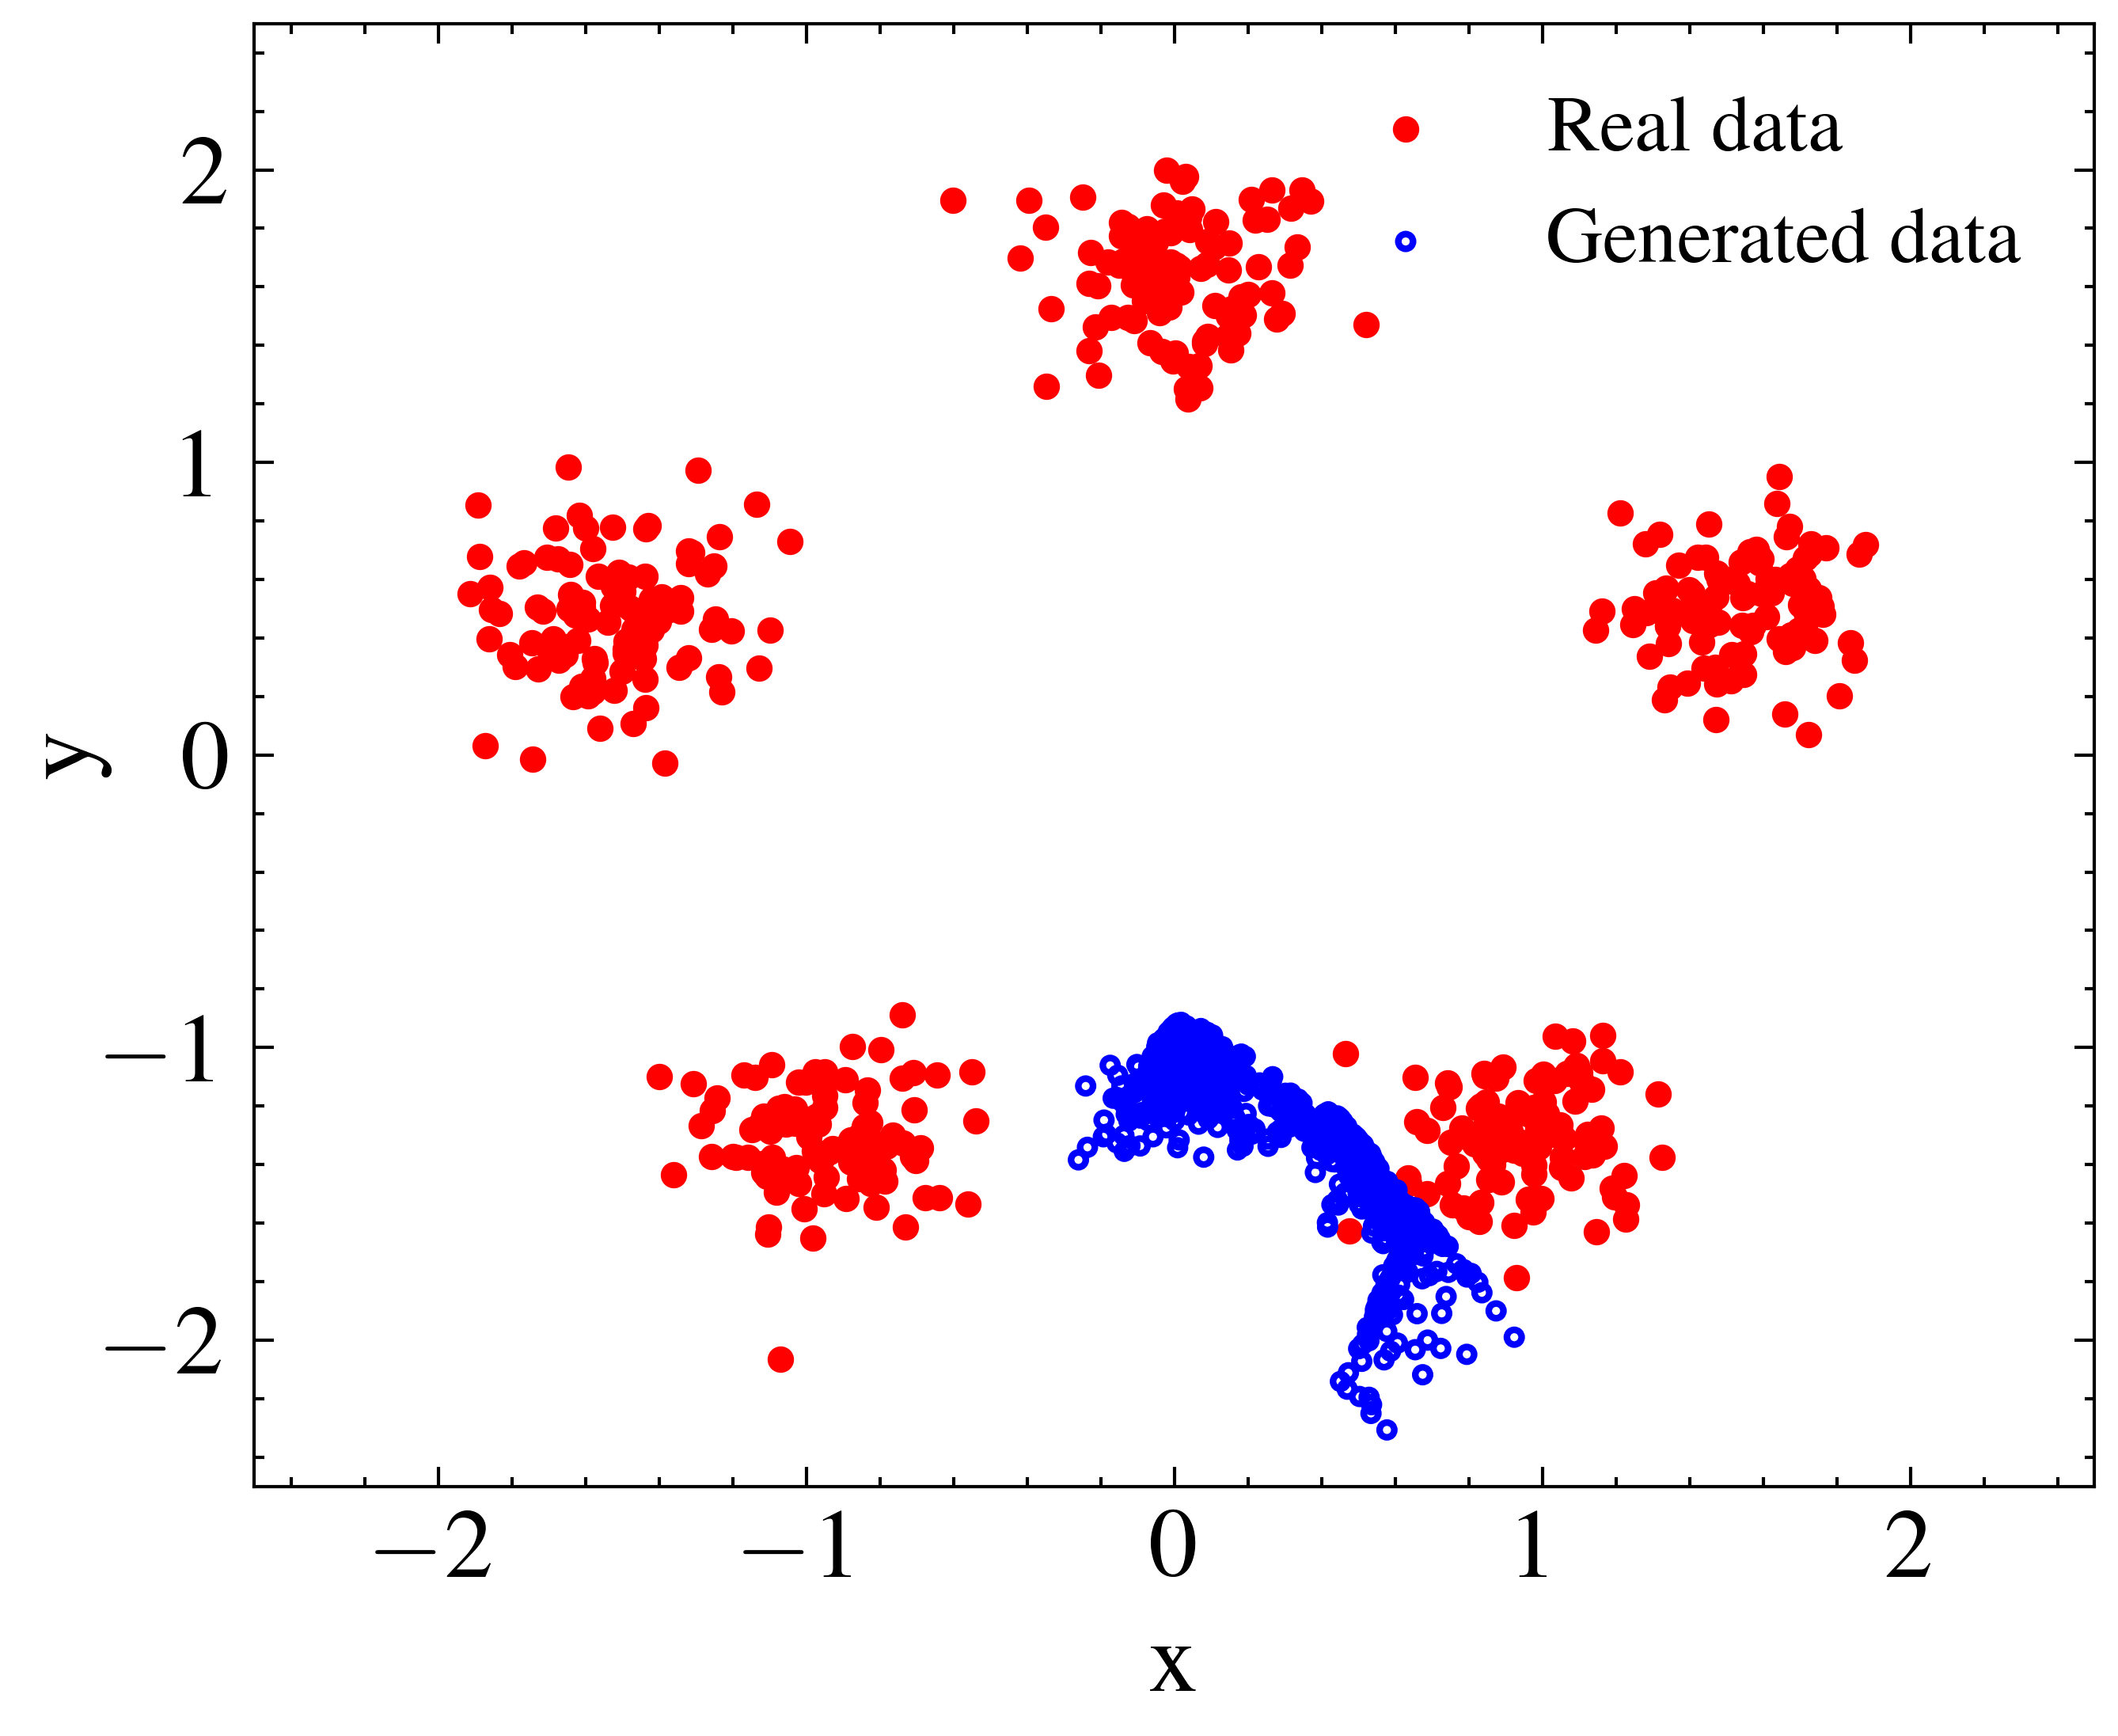


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.0140
Precision（生成样本落入真实密度区域比例）: 0.1790


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742  ###########连续5次随机种子看看是否成功42, 23, 683，83
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
epoch_generator_grad_norm = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")



np.save("D:/PRE2023 2025/epoch_generator_grad_norm742.npy", epoch_generator_grad_norm)


Epoch 0: D Loss: 1.3931, G Loss: -0.6526
Epoch 100: D Loss: 1.2867, G Loss: -0.6219
Epoch 200: D Loss: 0.9310, G Loss: -0.3834
Epoch 300: D Loss: 1.1709, G Loss: -0.3681
Epoch 400: D Loss: 1.4836, G Loss: -0.7294
Epoch 500: D Loss: 0.9765, G Loss: -0.3163
Epoch 600: D Loss: 1.3088, G Loss: -0.6459
Epoch 700: D Loss: 1.4462, G Loss: -0.5207
Epoch 800: D Loss: 0.7661, G Loss: -0.3841
Epoch 900: D Loss: 1.2974, G Loss: -0.5265
Epoch 1000: D Loss: 0.9315, G Loss: -0.3609
Epoch 1100: D Loss: 0.9930, G Loss: -0.4728
Epoch 1200: D Loss: 0.7792, G Loss: -0.3350
Epoch 1300: D Loss: 0.7288, G Loss: -0.3054
Epoch 1400: D Loss: 0.7475, G Loss: -0.3195
Epoch 1500: D Loss: 0.7670, G Loss: -0.3223
Epoch 1600: D Loss: 0.8008, G Loss: -0.3256
Epoch 1700: D Loss: 0.8258, G Loss: -0.3434
Epoch 1800: D Loss: 3.9885, G Loss: -2.8128
Epoch 1900: D Loss: 0.5659, G Loss: -0.2103
Epoch 2000: D Loss: 0.5402, G Loss: -0.2004
Epoch 2100: D Loss: 0.5387, G Loss: -0.1831
Epoch 2200: D Loss: 1.7183, G Loss: -0.9876


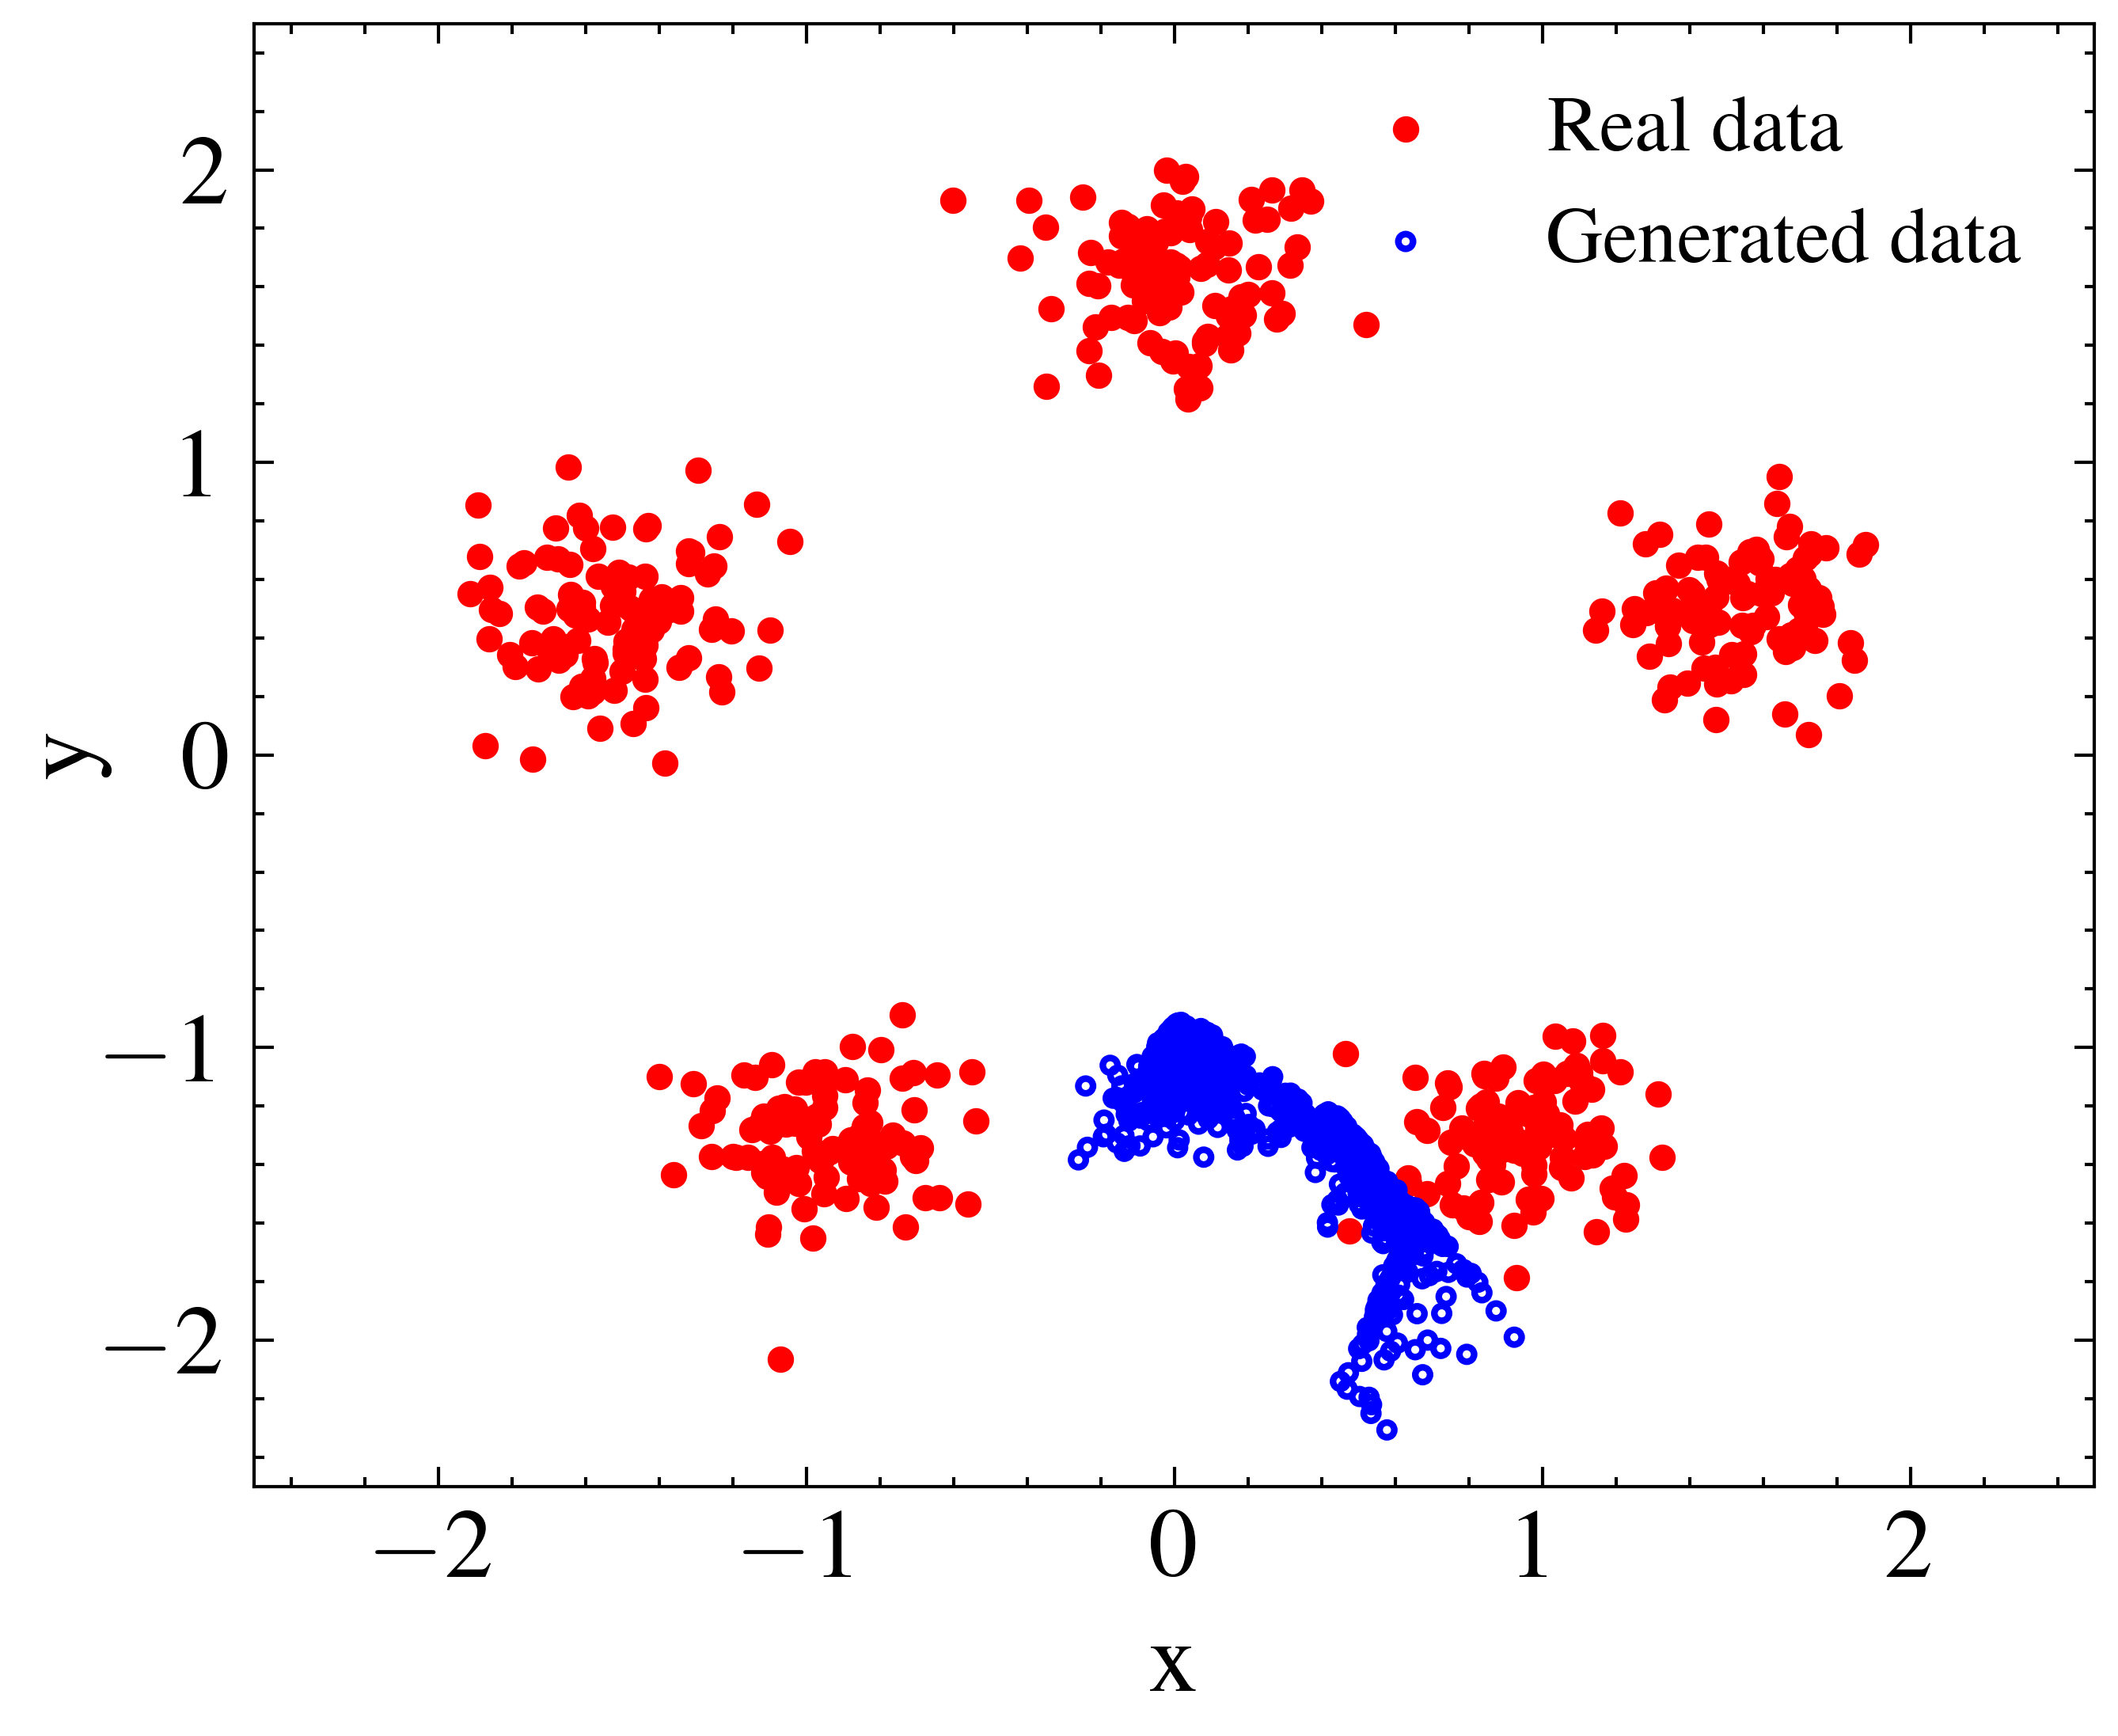


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.0140
Precision（生成样本落入真实密度区域比例）: 0.1790
生成样本已保存npy


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742  ###########连续5次随机种子看看是否成功42, 23, 683，83
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")


np.save("D:/PRE2023 2025/generated_samples742.npy", samples)
print("生成样本已保存npy")

In [7]:
####################2025年7-12

Epoch 0: D Loss: 1.4216, G Loss: -0.5701, G Grad Norm^2: 0.002256
Epoch 100: D Loss: 1.0841, G Loss: -0.5056, G Grad Norm^2: 0.035738
Epoch 200: D Loss: 0.6983, G Loss: -0.2423, G Grad Norm^2: 7.538057
Epoch 300: D Loss: 0.7835, G Loss: -0.2475, G Grad Norm^2: 0.176890
Epoch 400: D Loss: 0.8511, G Loss: -0.4369, G Grad Norm^2: 62.603439
Epoch 500: D Loss: 0.7264, G Loss: -0.2860, G Grad Norm^2: 0.545070
Epoch 600: D Loss: 0.6570, G Loss: -0.2678, G Grad Norm^2: 1.204099
Epoch 700: D Loss: 0.6732, G Loss: -0.2906, G Grad Norm^2: 1.771049
Epoch 800: D Loss: 0.7114, G Loss: -0.3005, G Grad Norm^2: 2.556409
Epoch 900: D Loss: 0.7409, G Loss: -0.3243, G Grad Norm^2: 5.003427
Epoch 1000: D Loss: 1.1137, G Loss: -0.5349, G Grad Norm^2: 9.574709
Epoch 1100: D Loss: 0.8620, G Loss: -0.3864, G Grad Norm^2: 1.411679
Epoch 1200: D Loss: 0.8442, G Loss: -0.3800, G Grad Norm^2: 2.632863
Epoch 1300: D Loss: 0.9147, G Loss: -0.4401, G Grad Norm^2: 3.547912
Epoch 1400: D Loss: 0.9288, G Loss: -0.4273, 

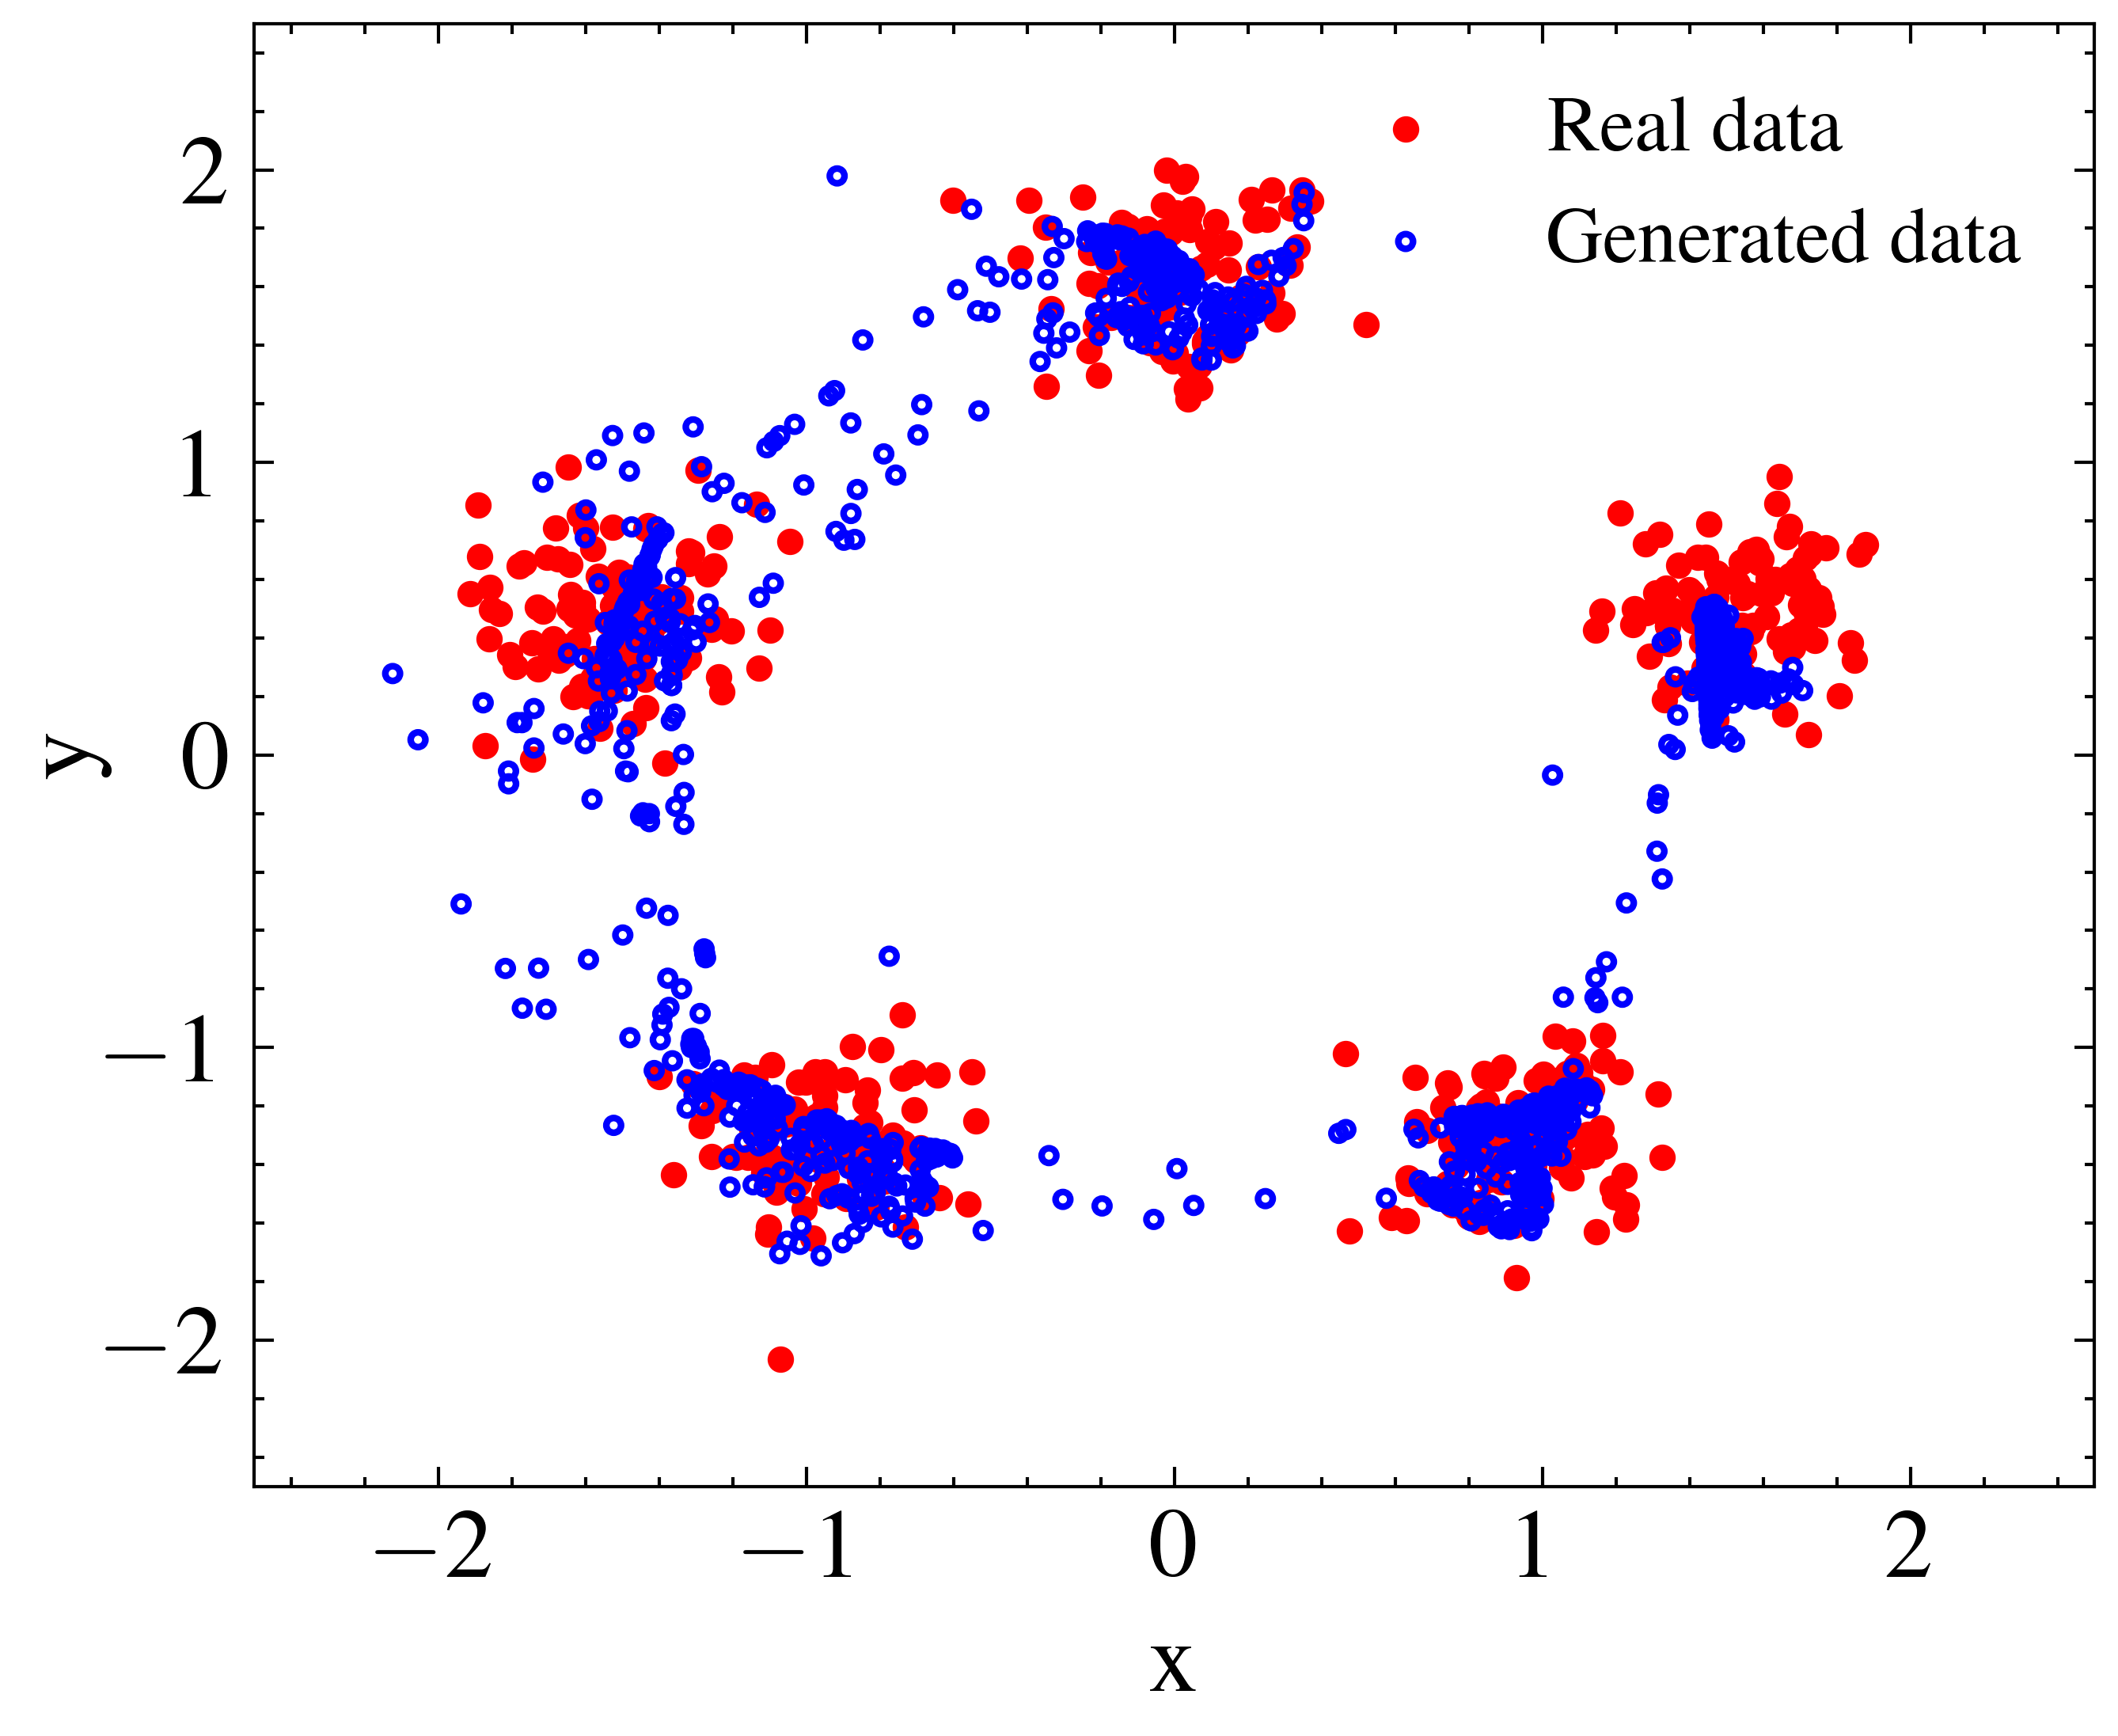


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.7180
Precision（生成样本落入真实密度区域比例）: 0.8950


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class GEU(nn.Module):
    def __init__(self, init_sigma=0.5):  # 建议默认值就写 1.0（浮点数）
        super(GEU, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.GEU(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.GEU.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")


np.save("D:/PRE2023 2025/sampleGEU742.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normGEU742.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesGEU742.npy", epoch_sigma_values)

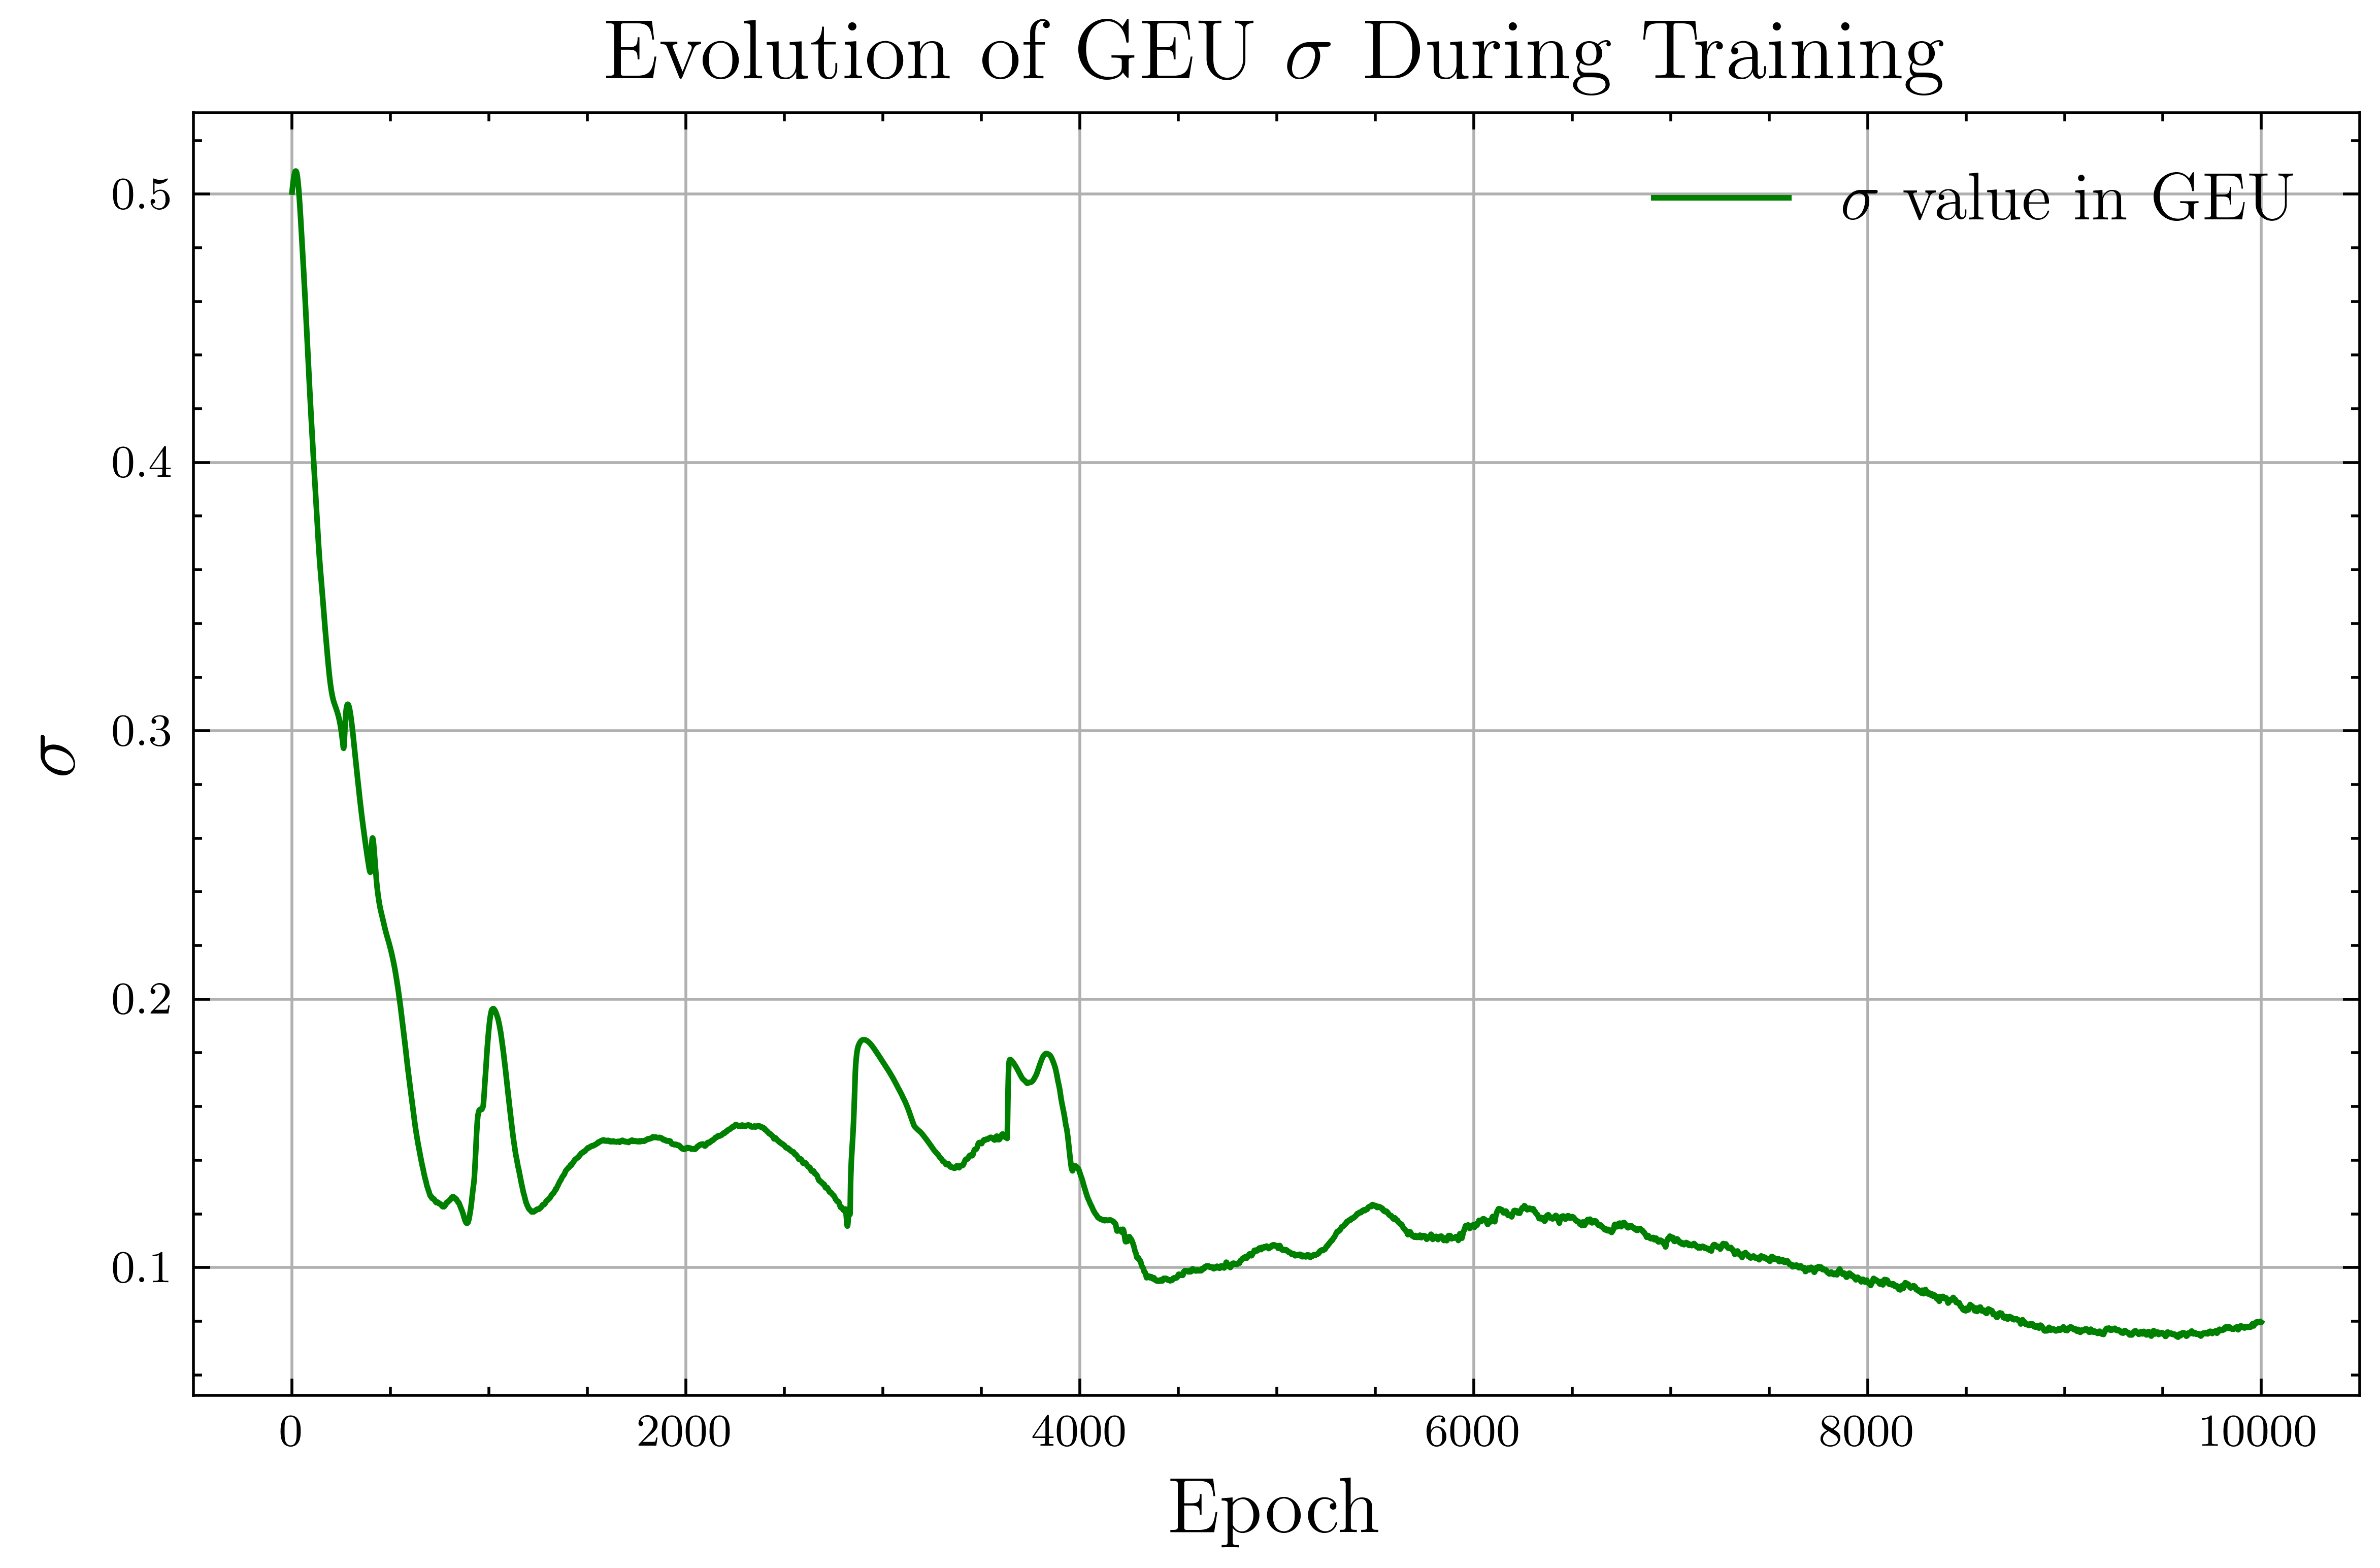

In [10]:
np.save("D:/PRE2023 2025/sampleGEU742.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normGEU742.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesGEU742.npy", epoch_sigma_values)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value in GEU', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of GEU $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()


Epoch 0: D Loss: 1.9559, G Loss: -0.2318, G Grad Norm^2: 0.014575
Epoch 100: D Loss: 0.8384, G Loss: -0.4097, G Grad Norm^2: 0.050360
Epoch 200: D Loss: 0.5276, G Loss: -0.1756, G Grad Norm^2: 0.337383
Epoch 300: D Loss: 0.6232, G Loss: -0.2944, G Grad Norm^2: 1.958971
Epoch 400: D Loss: 0.6147, G Loss: -0.2732, G Grad Norm^2: 2.469717
Epoch 500: D Loss: 0.7046, G Loss: -0.2990, G Grad Norm^2: 1.574471
Epoch 600: D Loss: 0.6828, G Loss: -0.2863, G Grad Norm^2: 3.662808
Epoch 700: D Loss: 0.7443, G Loss: -0.3192, G Grad Norm^2: 1.329132
Epoch 800: D Loss: 0.8244, G Loss: -0.3531, G Grad Norm^2: 4.655135
Epoch 900: D Loss: 0.8165, G Loss: -0.3192, G Grad Norm^2: 0.676980
Epoch 1000: D Loss: 0.8220, G Loss: -0.3371, G Grad Norm^2: 0.133398
Epoch 1100: D Loss: 0.8194, G Loss: -0.3418, G Grad Norm^2: 0.086011
Epoch 1200: D Loss: 0.8114, G Loss: -0.3268, G Grad Norm^2: 0.070564
Epoch 1300: D Loss: 0.8193, G Loss: -0.3376, G Grad Norm^2: 0.108008
Epoch 1400: D Loss: 0.8070, G Loss: -0.3185, G

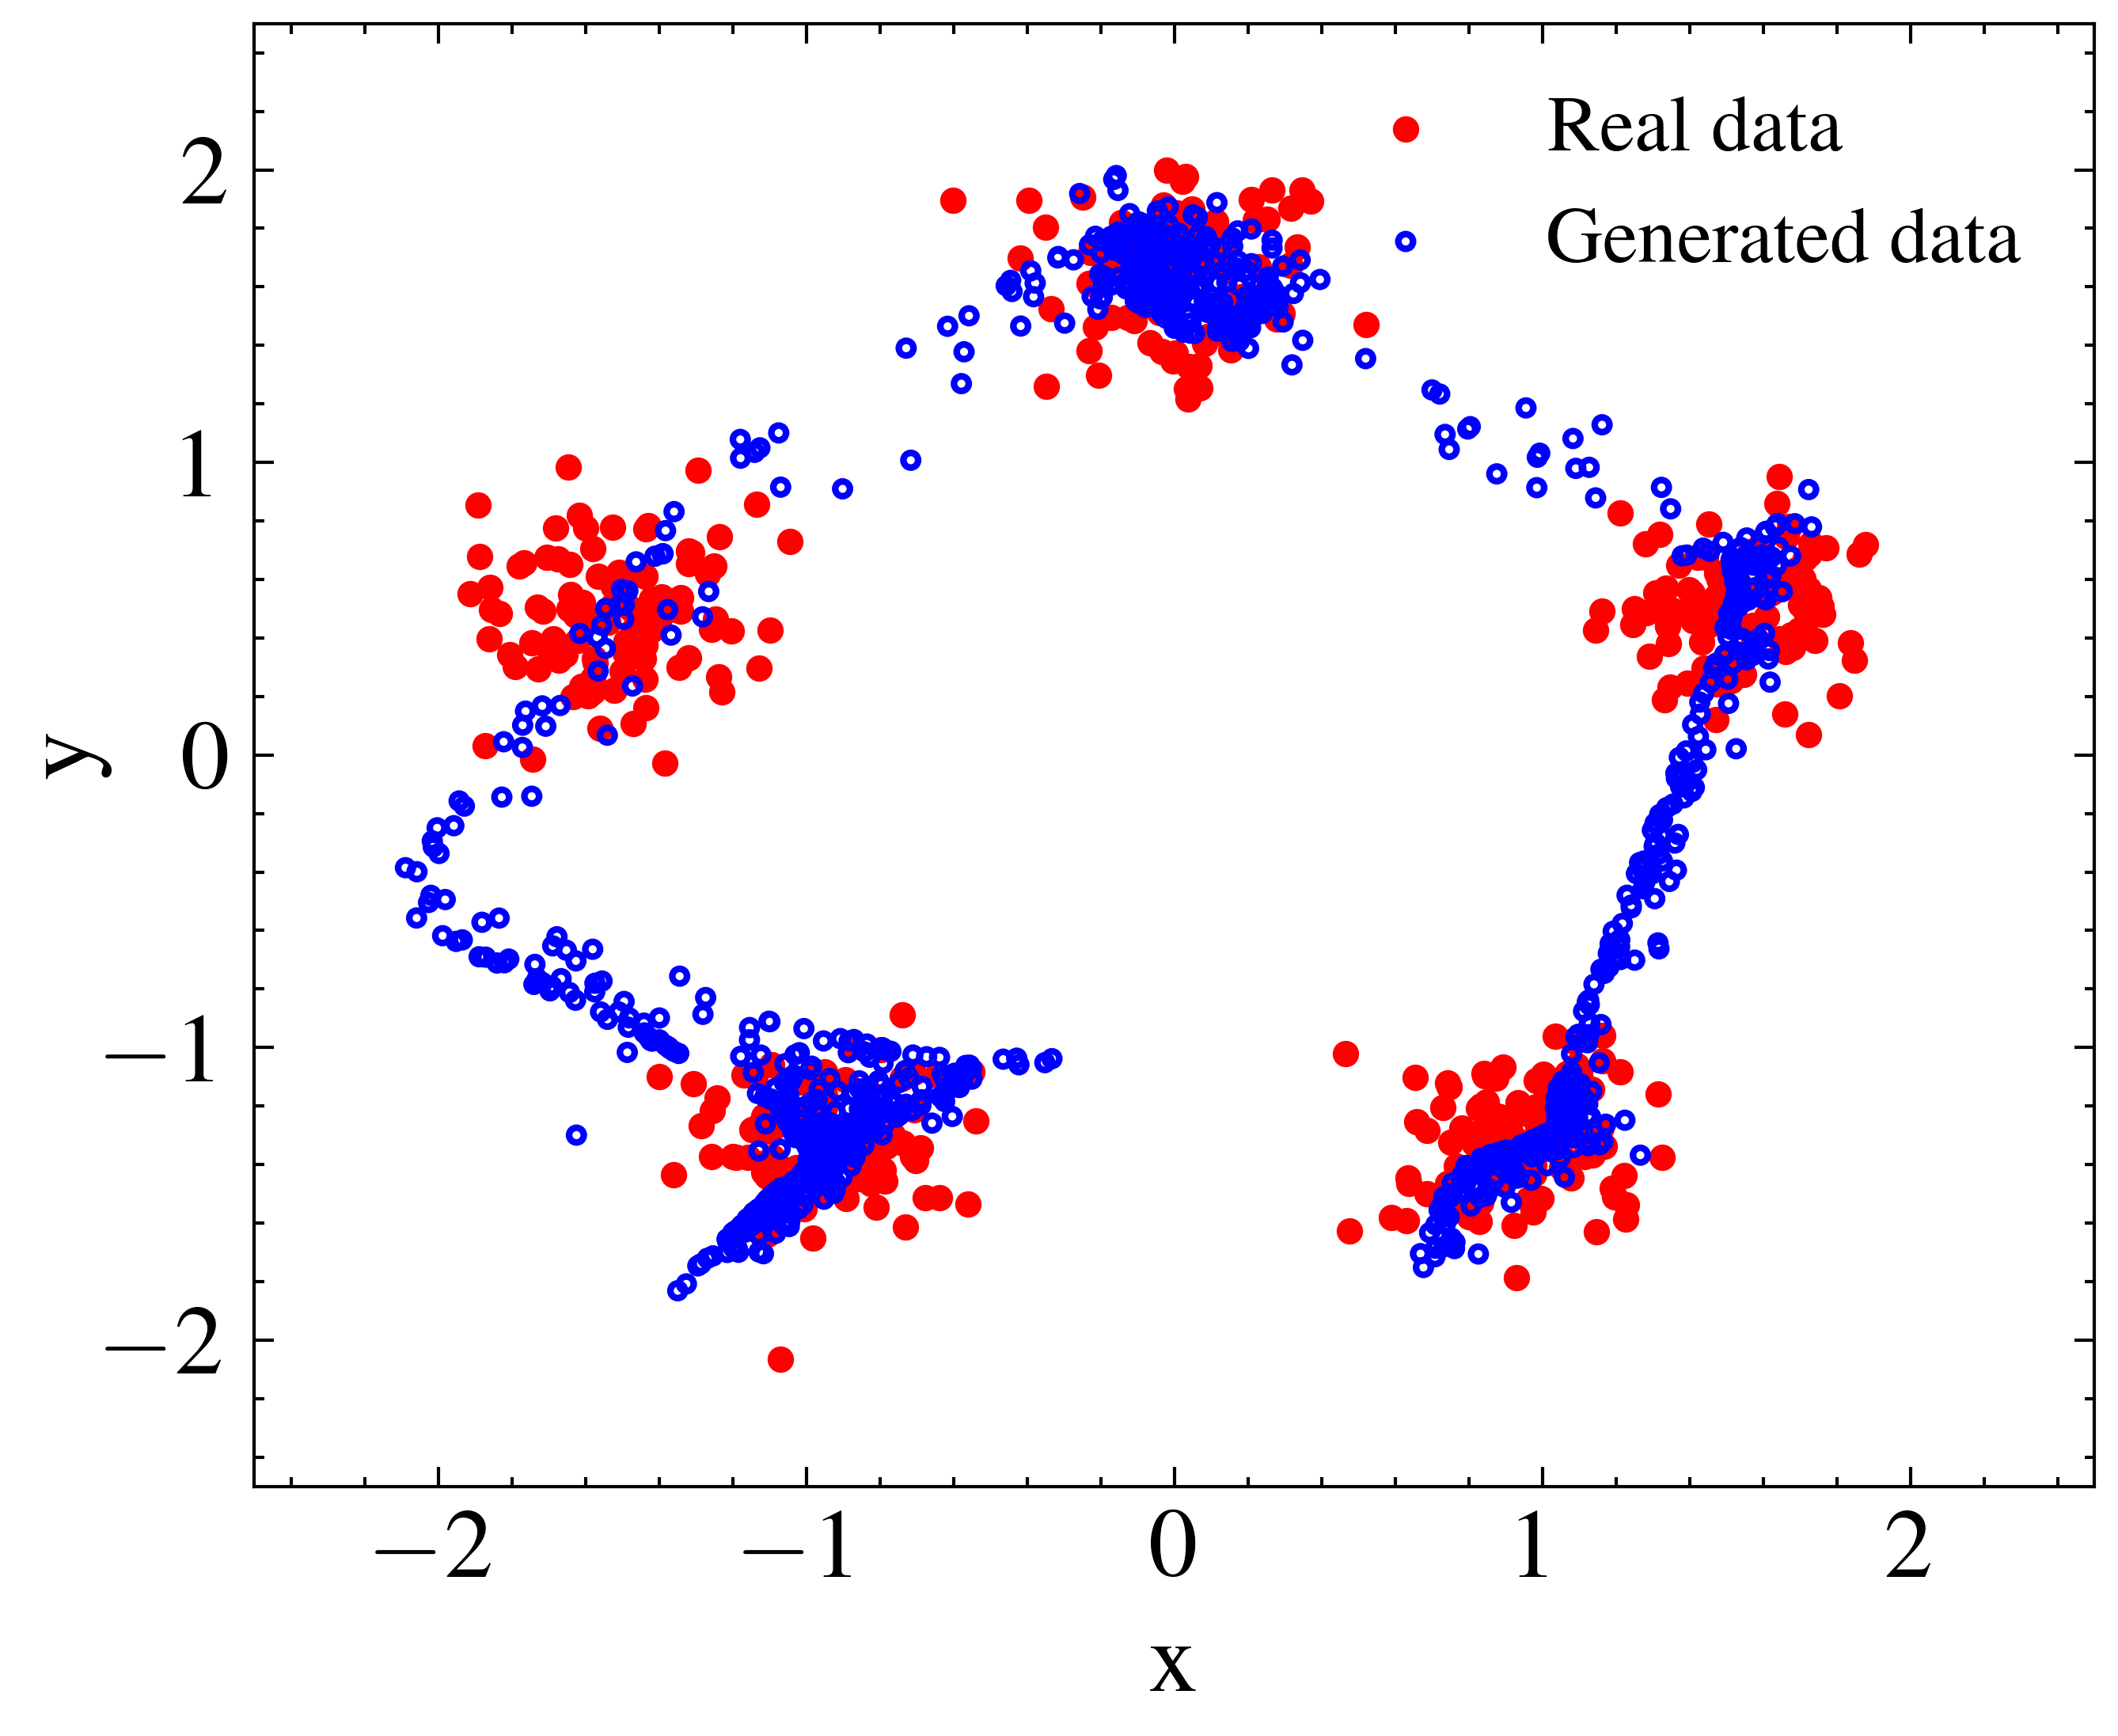


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.7440
Precision（生成样本落入真实密度区域比例）: 0.8020


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class GEU(nn.Module):
    def __init__(self, init_sigma=0.1):  
        super(GEU, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.GEU(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.GEU.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

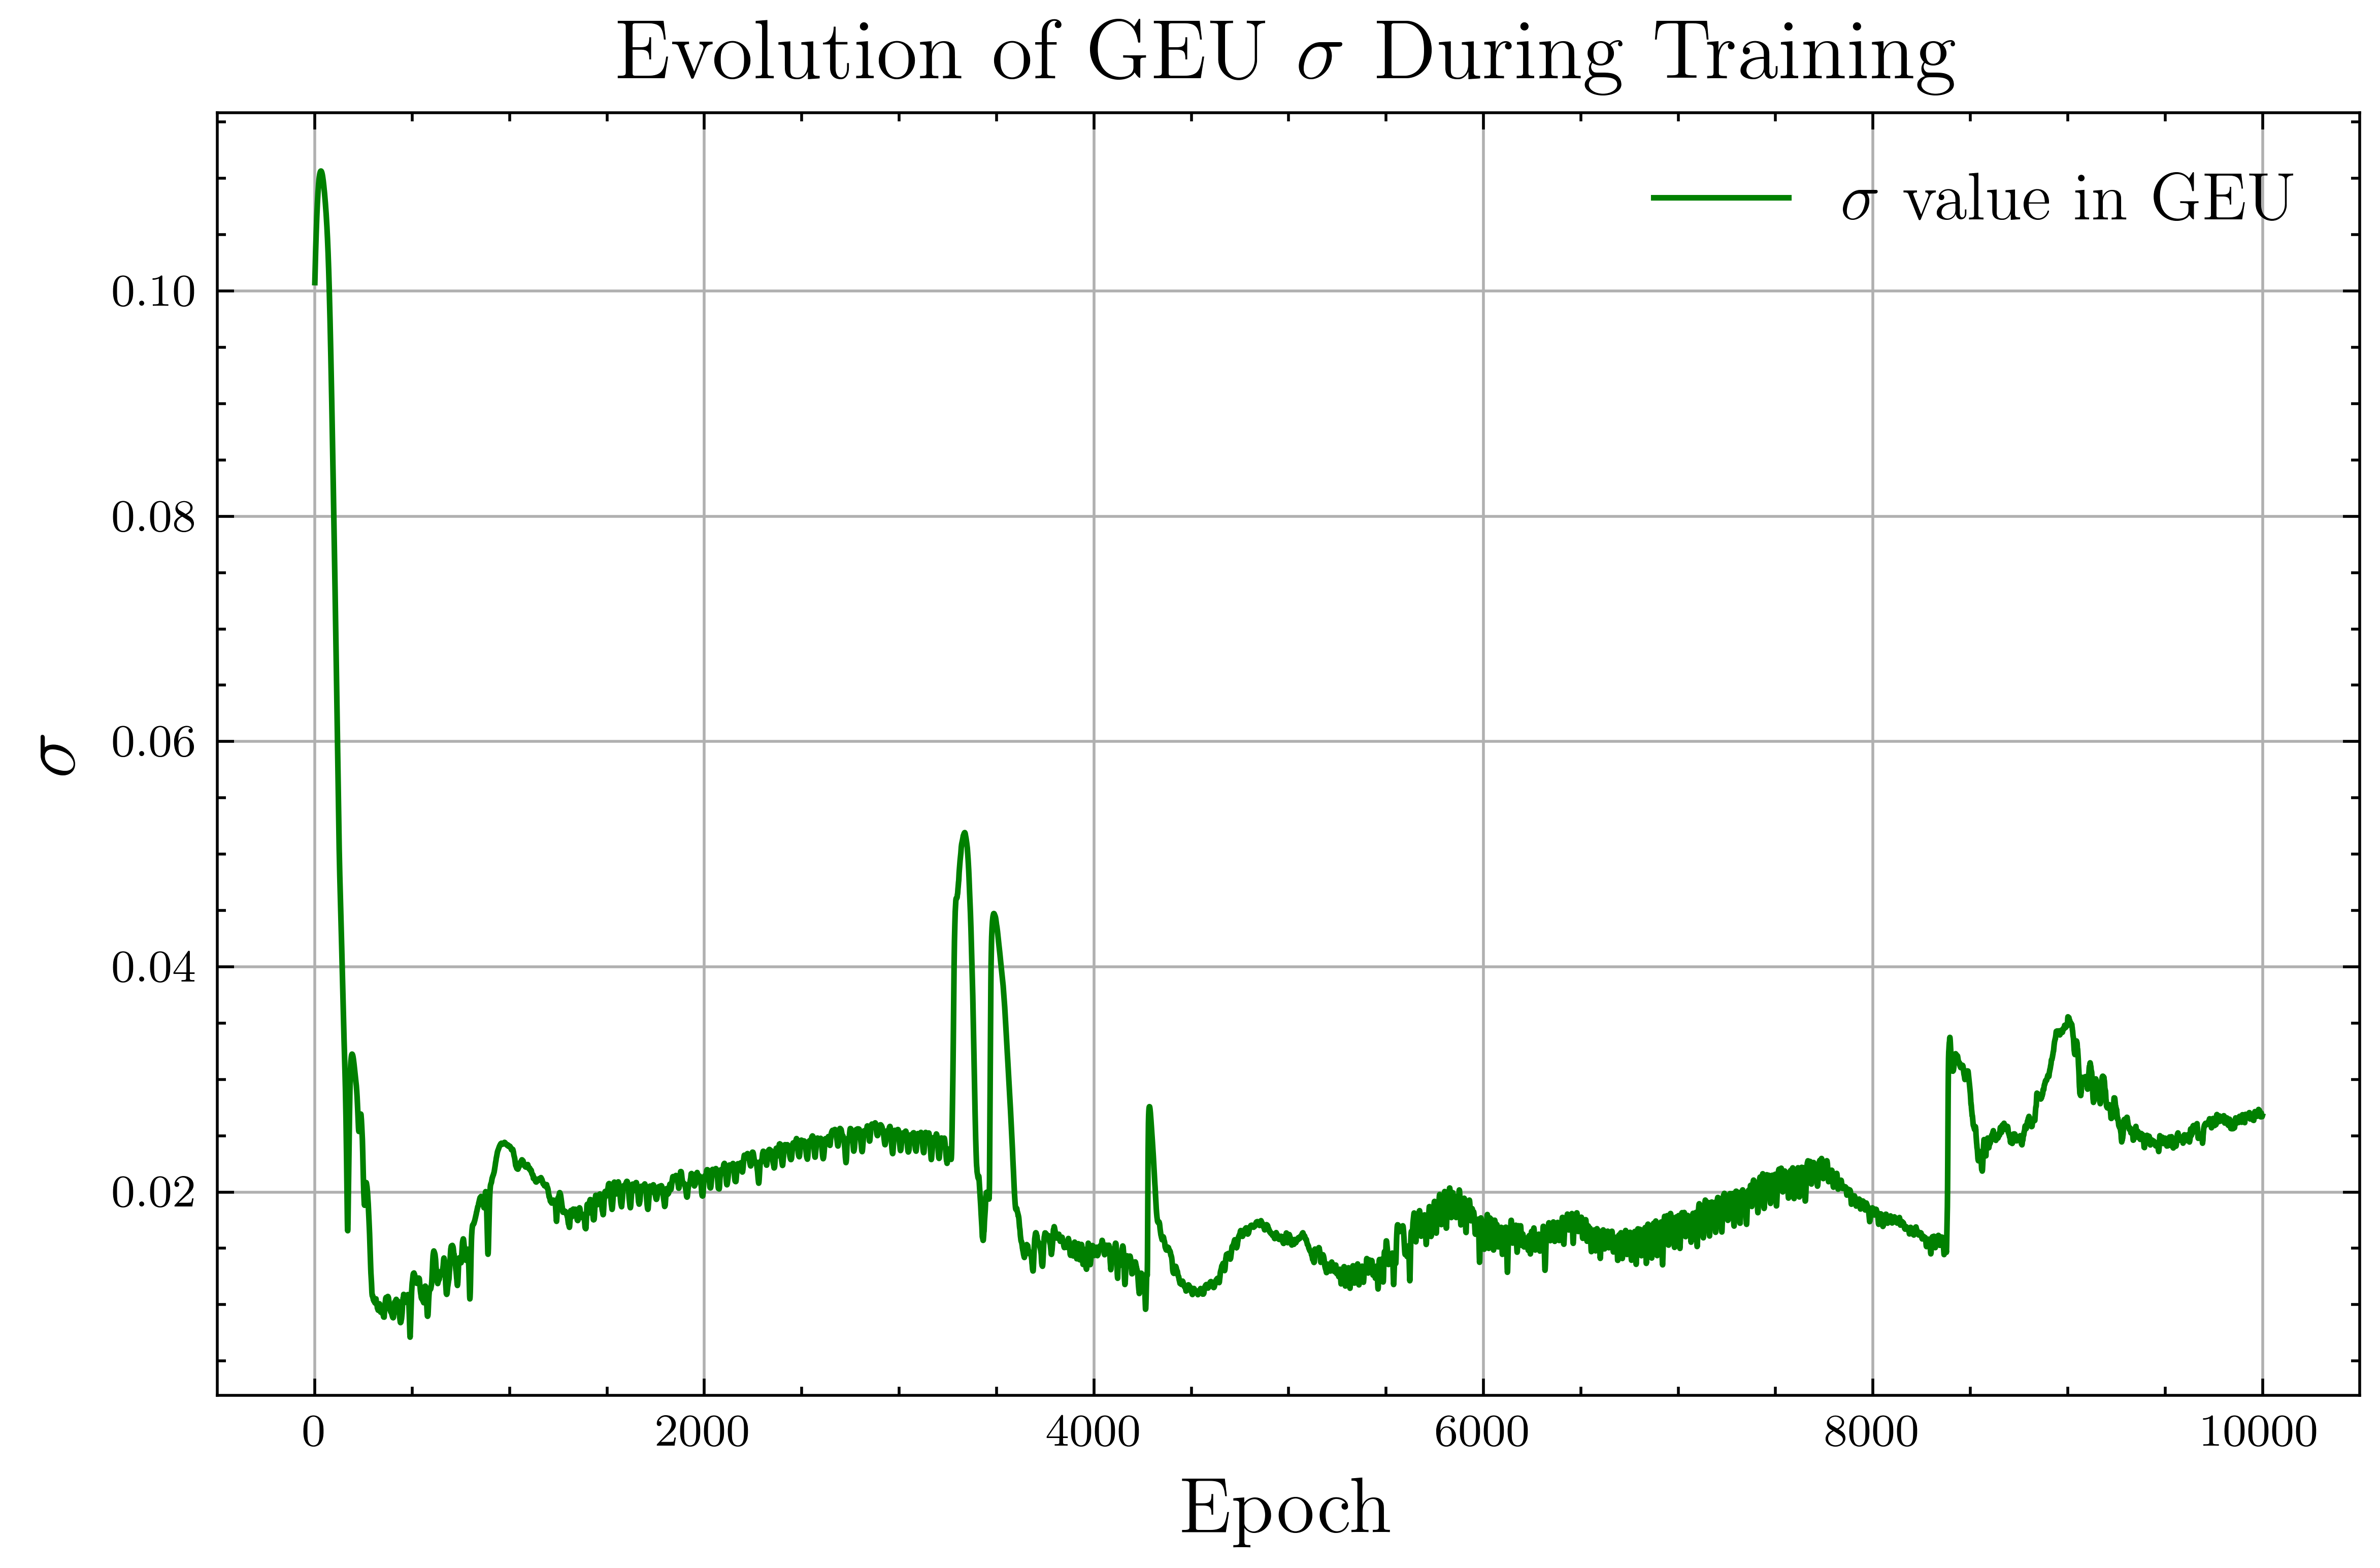

In [5]:
np.save("D:/PRE2023 2025/sampleGEU742-2.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normGEU742-2.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuesGEU742-2.npy", epoch_sigma_values)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value in GEU', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of GEU $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

Epoch 0: D Loss: 1.4585, G Loss: -0.5086, G Grad Norm^2: 0.004589
Epoch 100: D Loss: 0.8970, G Loss: -0.4308, G Grad Norm^2: 0.075337
Epoch 200: D Loss: 0.6045, G Loss: -0.1972, G Grad Norm^2: 0.129638
Epoch 300: D Loss: 0.4274, G Loss: -0.2146, G Grad Norm^2: 4.943462
Epoch 400: D Loss: 0.6921, G Loss: -0.3094, G Grad Norm^2: 1.571356
Epoch 500: D Loss: 0.7174, G Loss: -0.3131, G Grad Norm^2: 1.810711
Epoch 600: D Loss: 0.7157, G Loss: -0.2997, G Grad Norm^2: 1.104301
Epoch 700: D Loss: 0.7452, G Loss: -0.3172, G Grad Norm^2: 0.431847
Epoch 800: D Loss: 0.7876, G Loss: -0.3211, G Grad Norm^2: 0.336030
Epoch 900: D Loss: 0.8075, G Loss: -0.3357, G Grad Norm^2: 0.172885
Epoch 1000: D Loss: 0.8243, G Loss: -0.3396, G Grad Norm^2: 0.104740
Epoch 1100: D Loss: 0.8237, G Loss: -0.3415, G Grad Norm^2: 0.044308
Epoch 1200: D Loss: 0.8295, G Loss: -0.3340, G Grad Norm^2: 0.049337
Epoch 1300: D Loss: 0.8240, G Loss: -0.3327, G Grad Norm^2: 0.103131
Epoch 1400: D Loss: 0.8367, G Loss: -0.3377, G

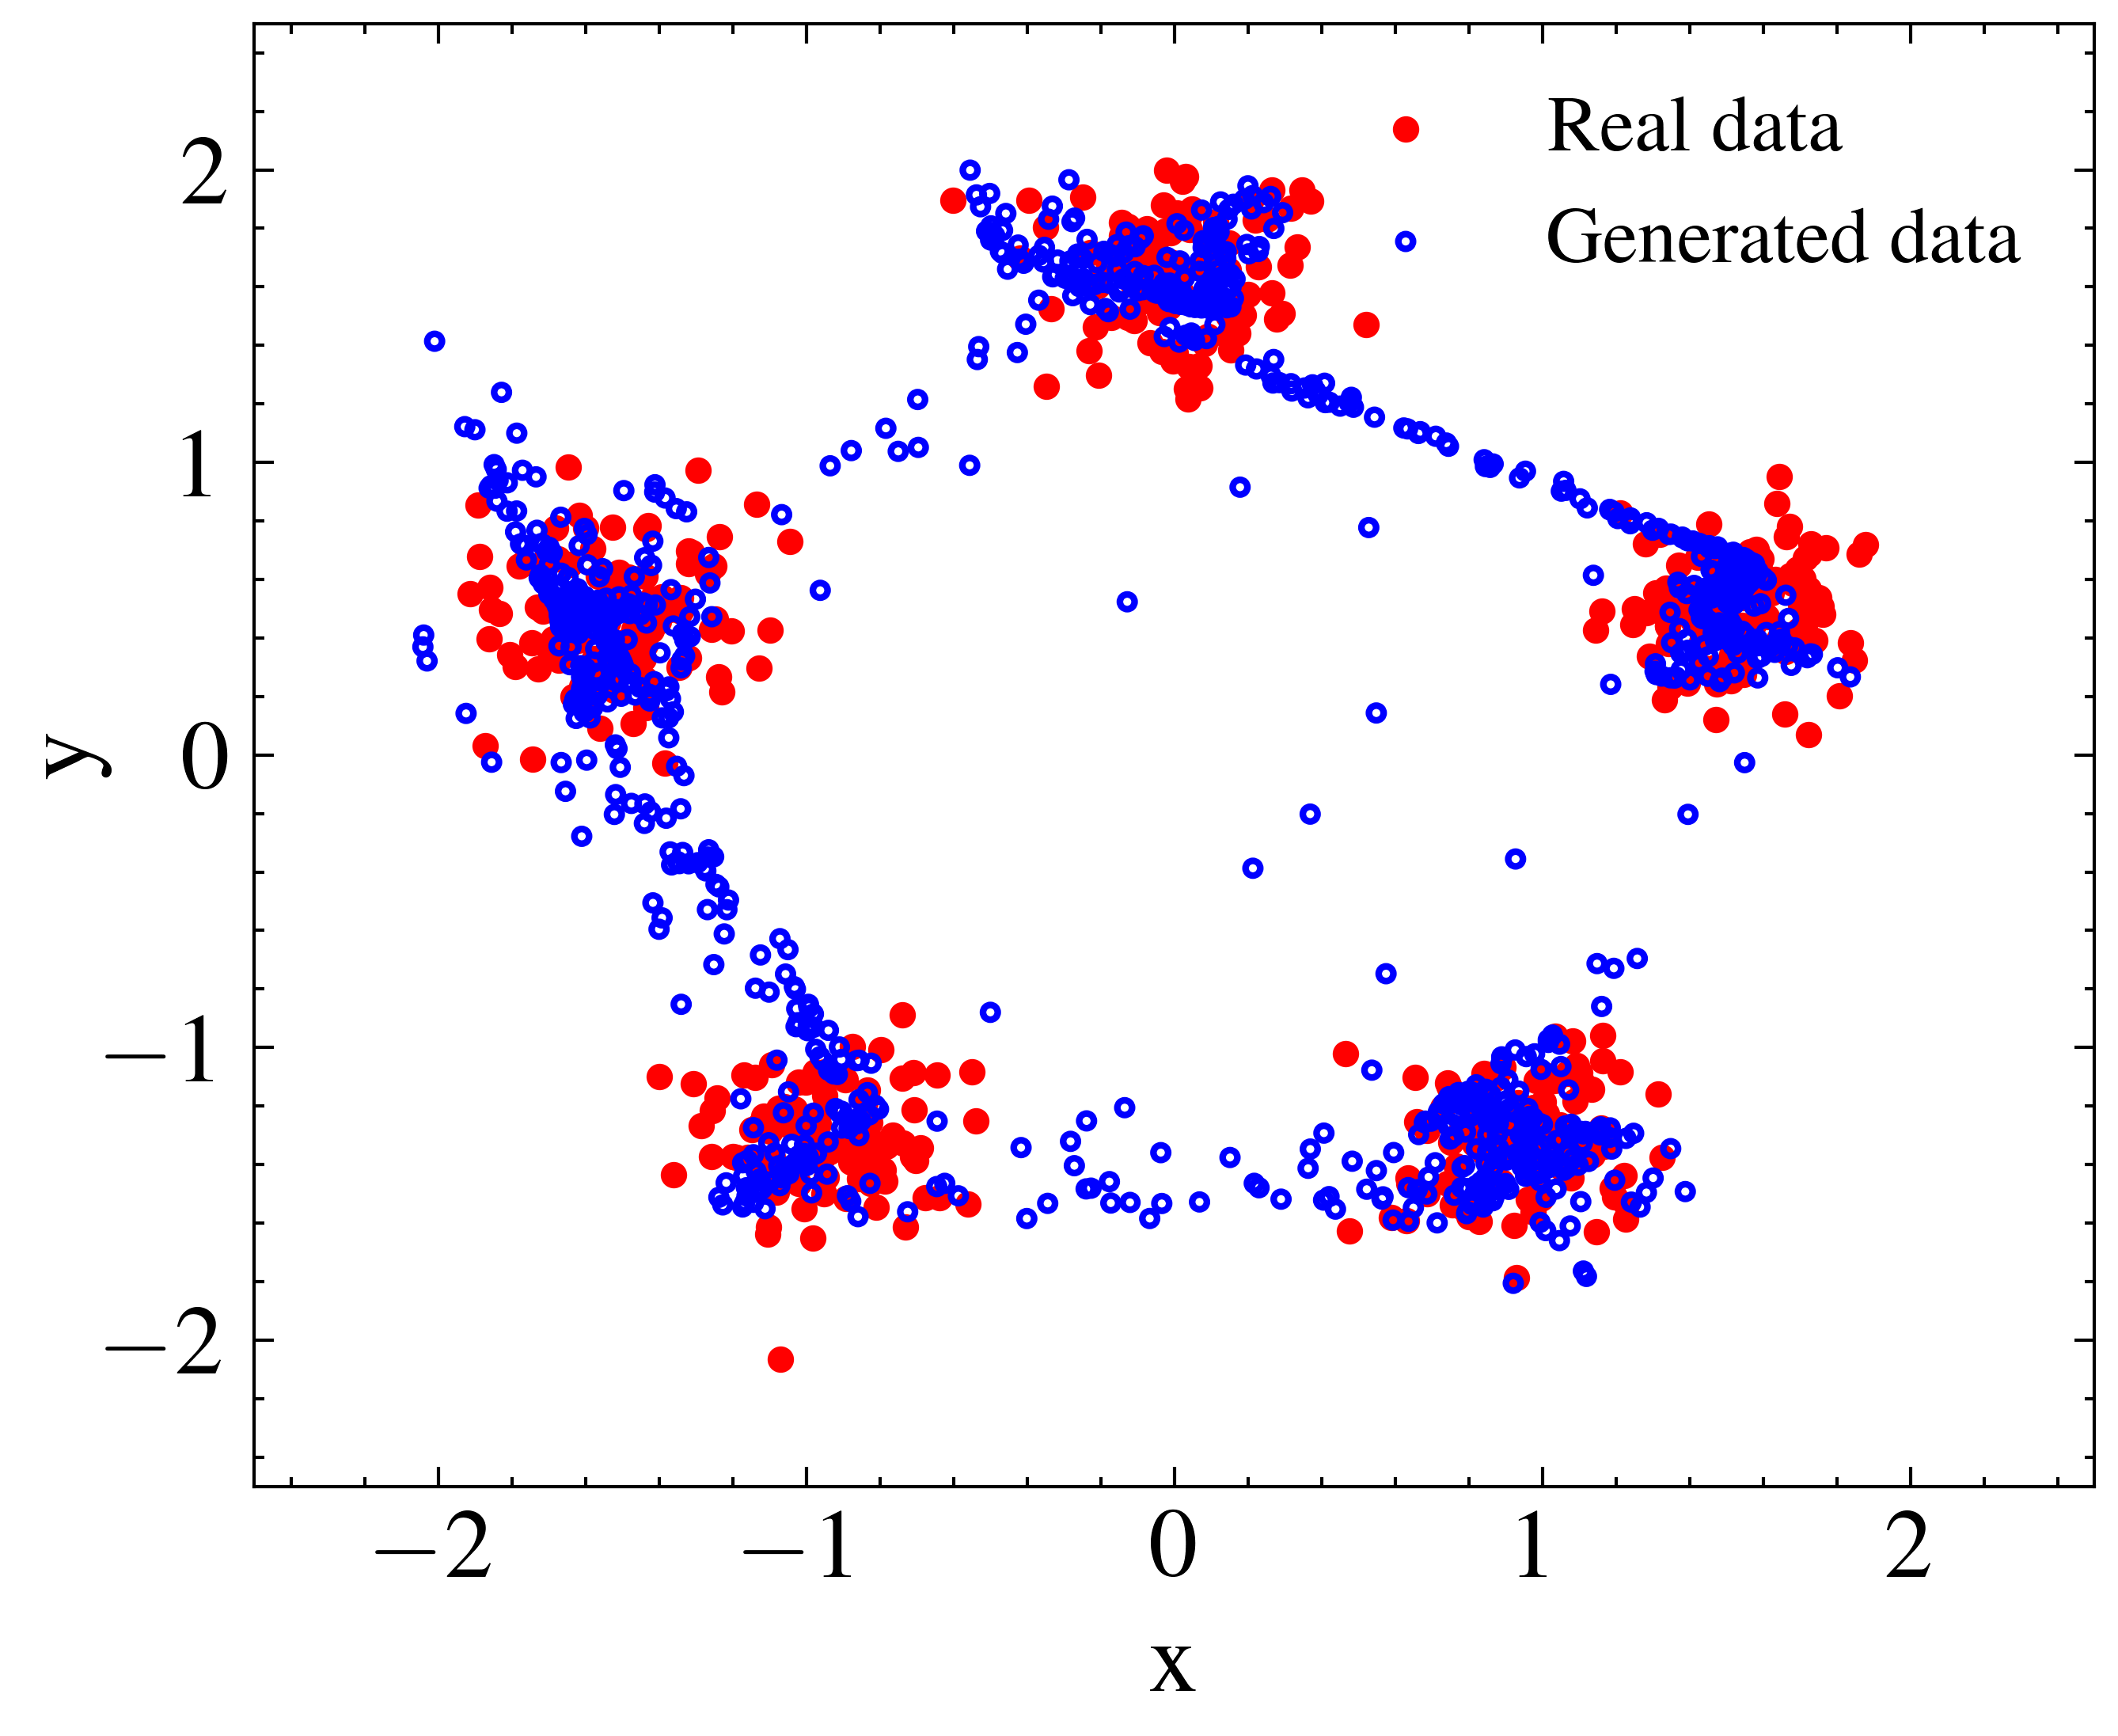


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.8780
Precision（生成样本落入真实密度区域比例）: 0.8210


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 742###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.2):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.vsigmoid = Vsig()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.vsigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []
epoch_generator_grad_norm = []
epoch_sigma_values = []

for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_generator_grad_norm = []  # ← 必须添加这一行
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))  # ← 新增记录
    epoch_sigma_values.append(discriminator.vsigmoid.sigma.item())

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, "
              f"G Loss: {np.mean(batch_generator_loss):.4f}, "
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")
        
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

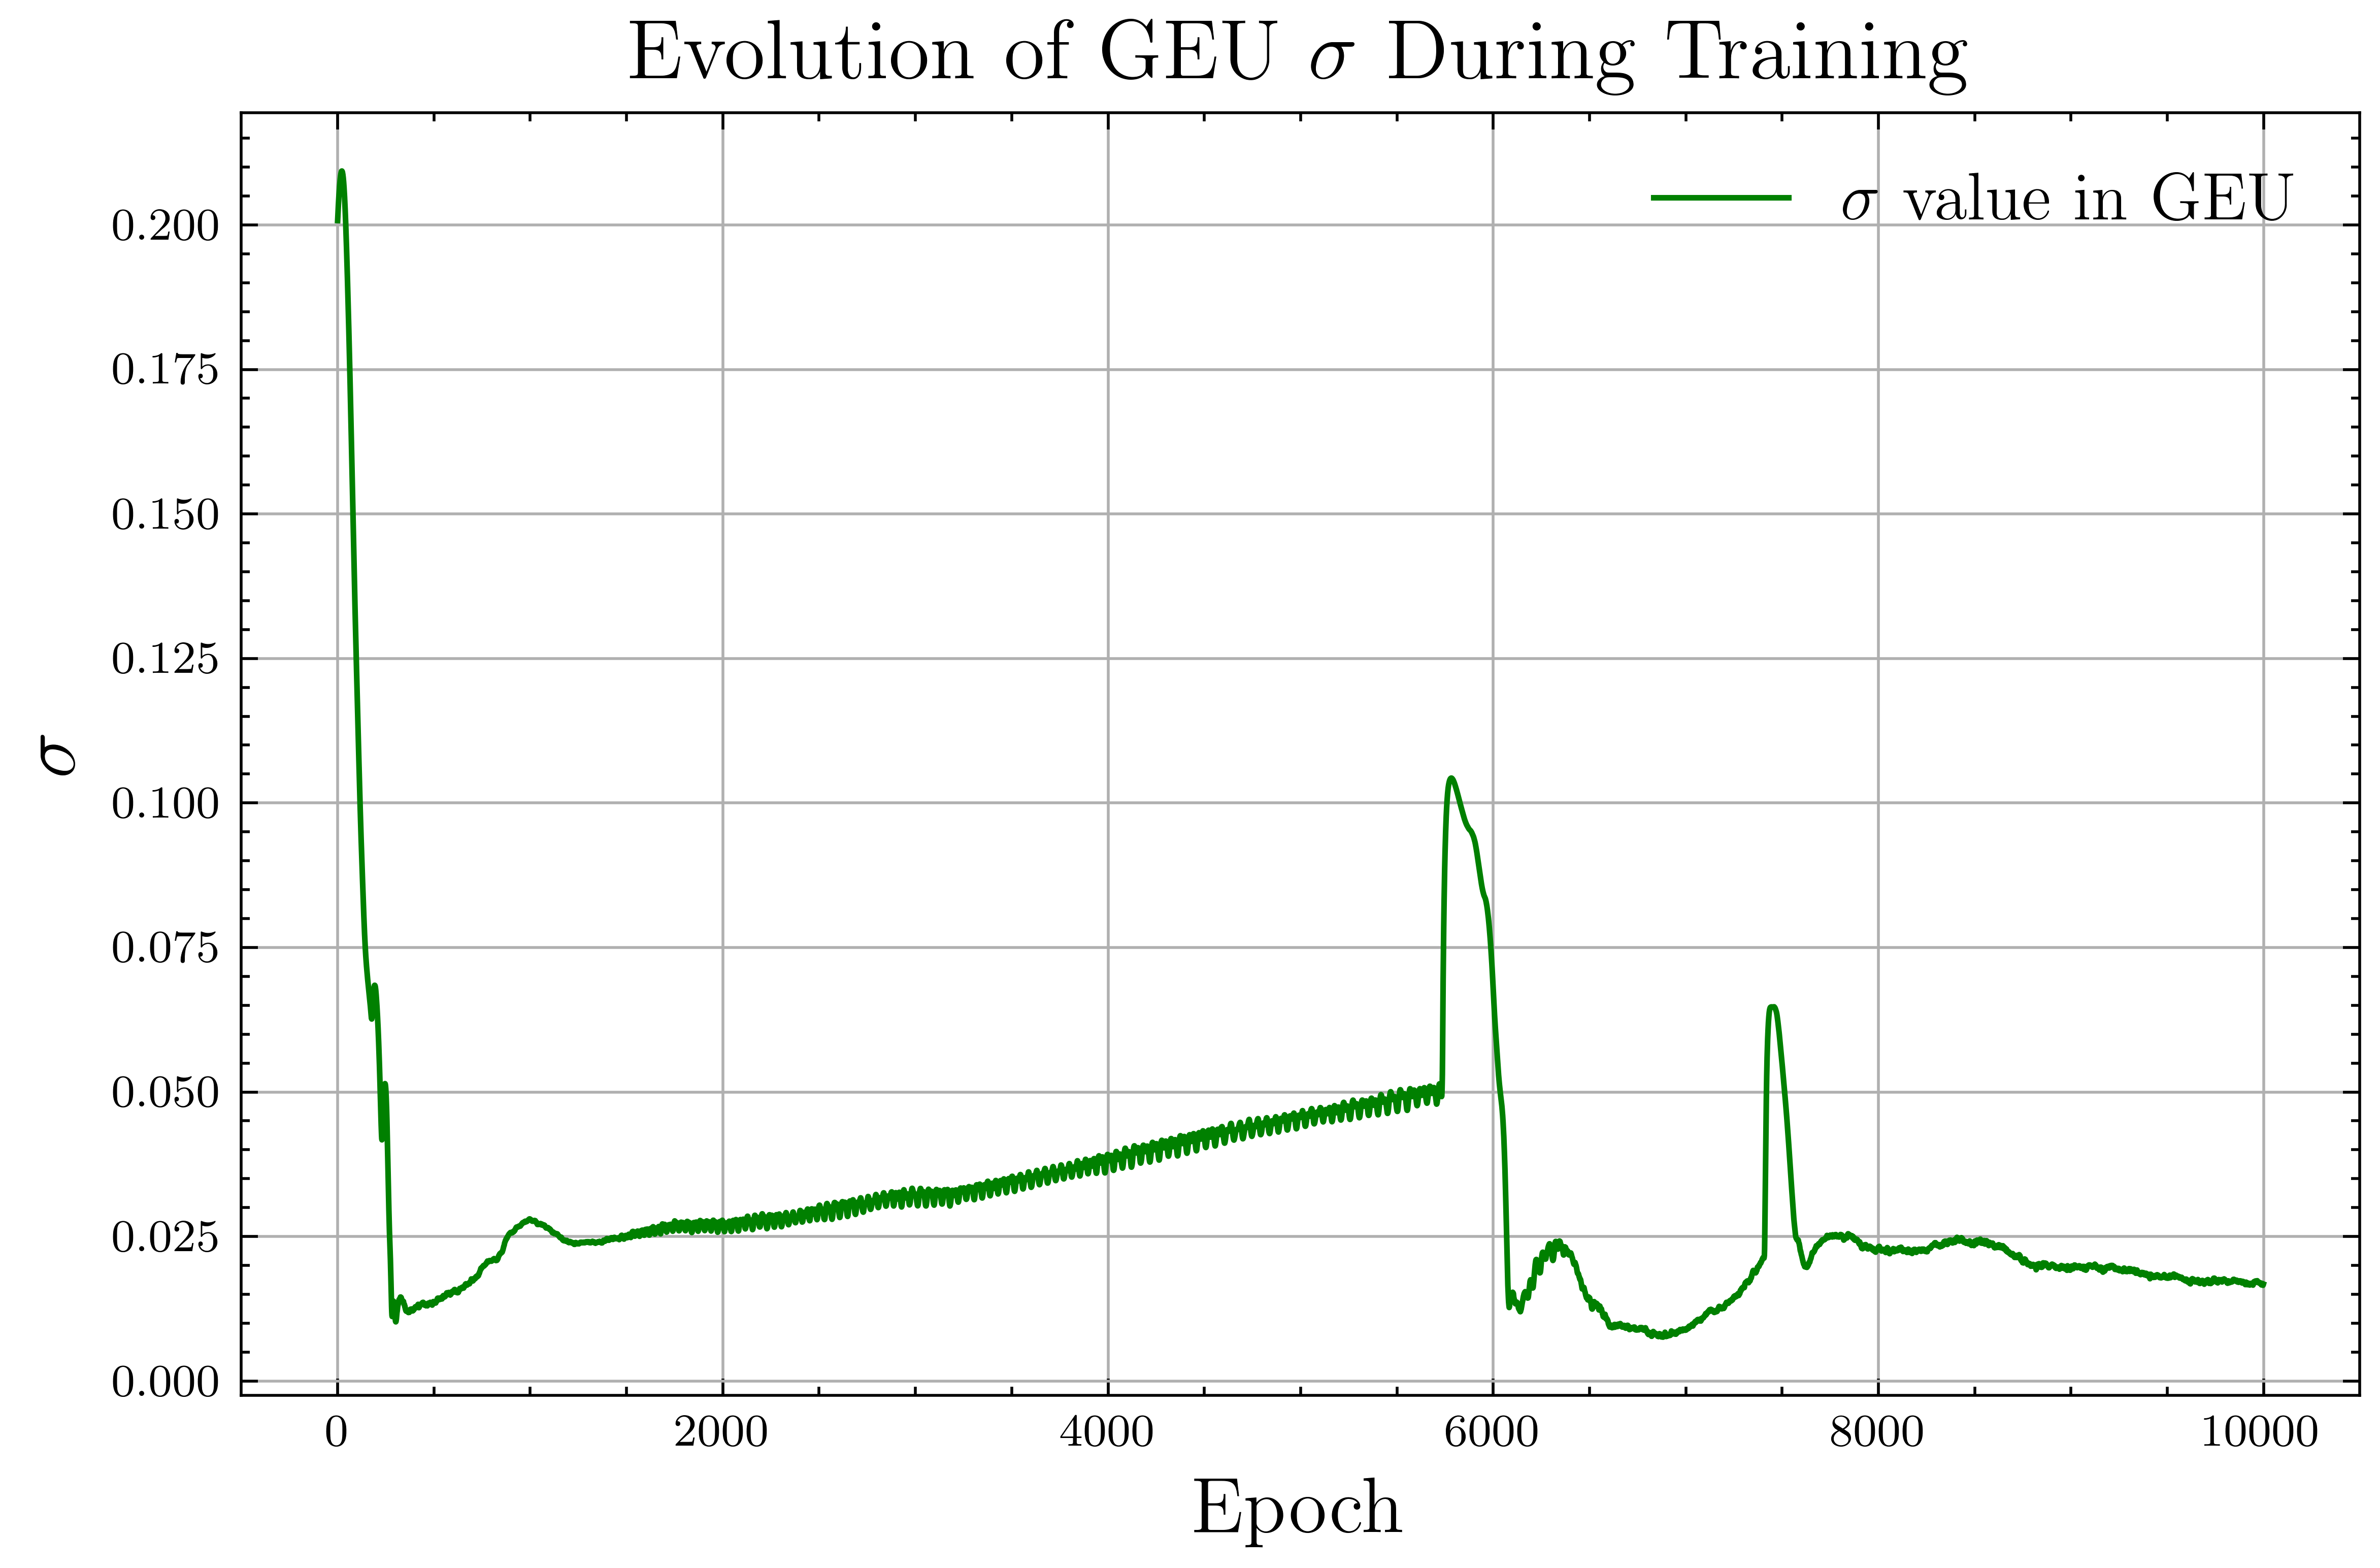

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载 sigma 数据
#epoch_sigma_values = np.load("D:/PRE2023 2025/epoch_sigma_values742.npy")

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(epoch_sigma_values, label=r'$\sigma$ value in GEU', color='green')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.title('Evolution of GEU $\sigma$ During Training', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("D:/PRE2023 2025/sigma742.pdf")  # 可选保存为 PDF
plt.show()

In [14]:
np.save("D:/PRE2023 2025/sample742sig.npy", samples)
np.save("D:/PRE2023 2025/epoch_generator_grad_normsig742.npy", epoch_generator_grad_norm)
np.save("D:/PRE2023 2025/epoch_sigma_valuessig742.npy", epoch_sigma_values)

In [18]:
print(epoch_sigma_values[-1])

0.01674511469900608


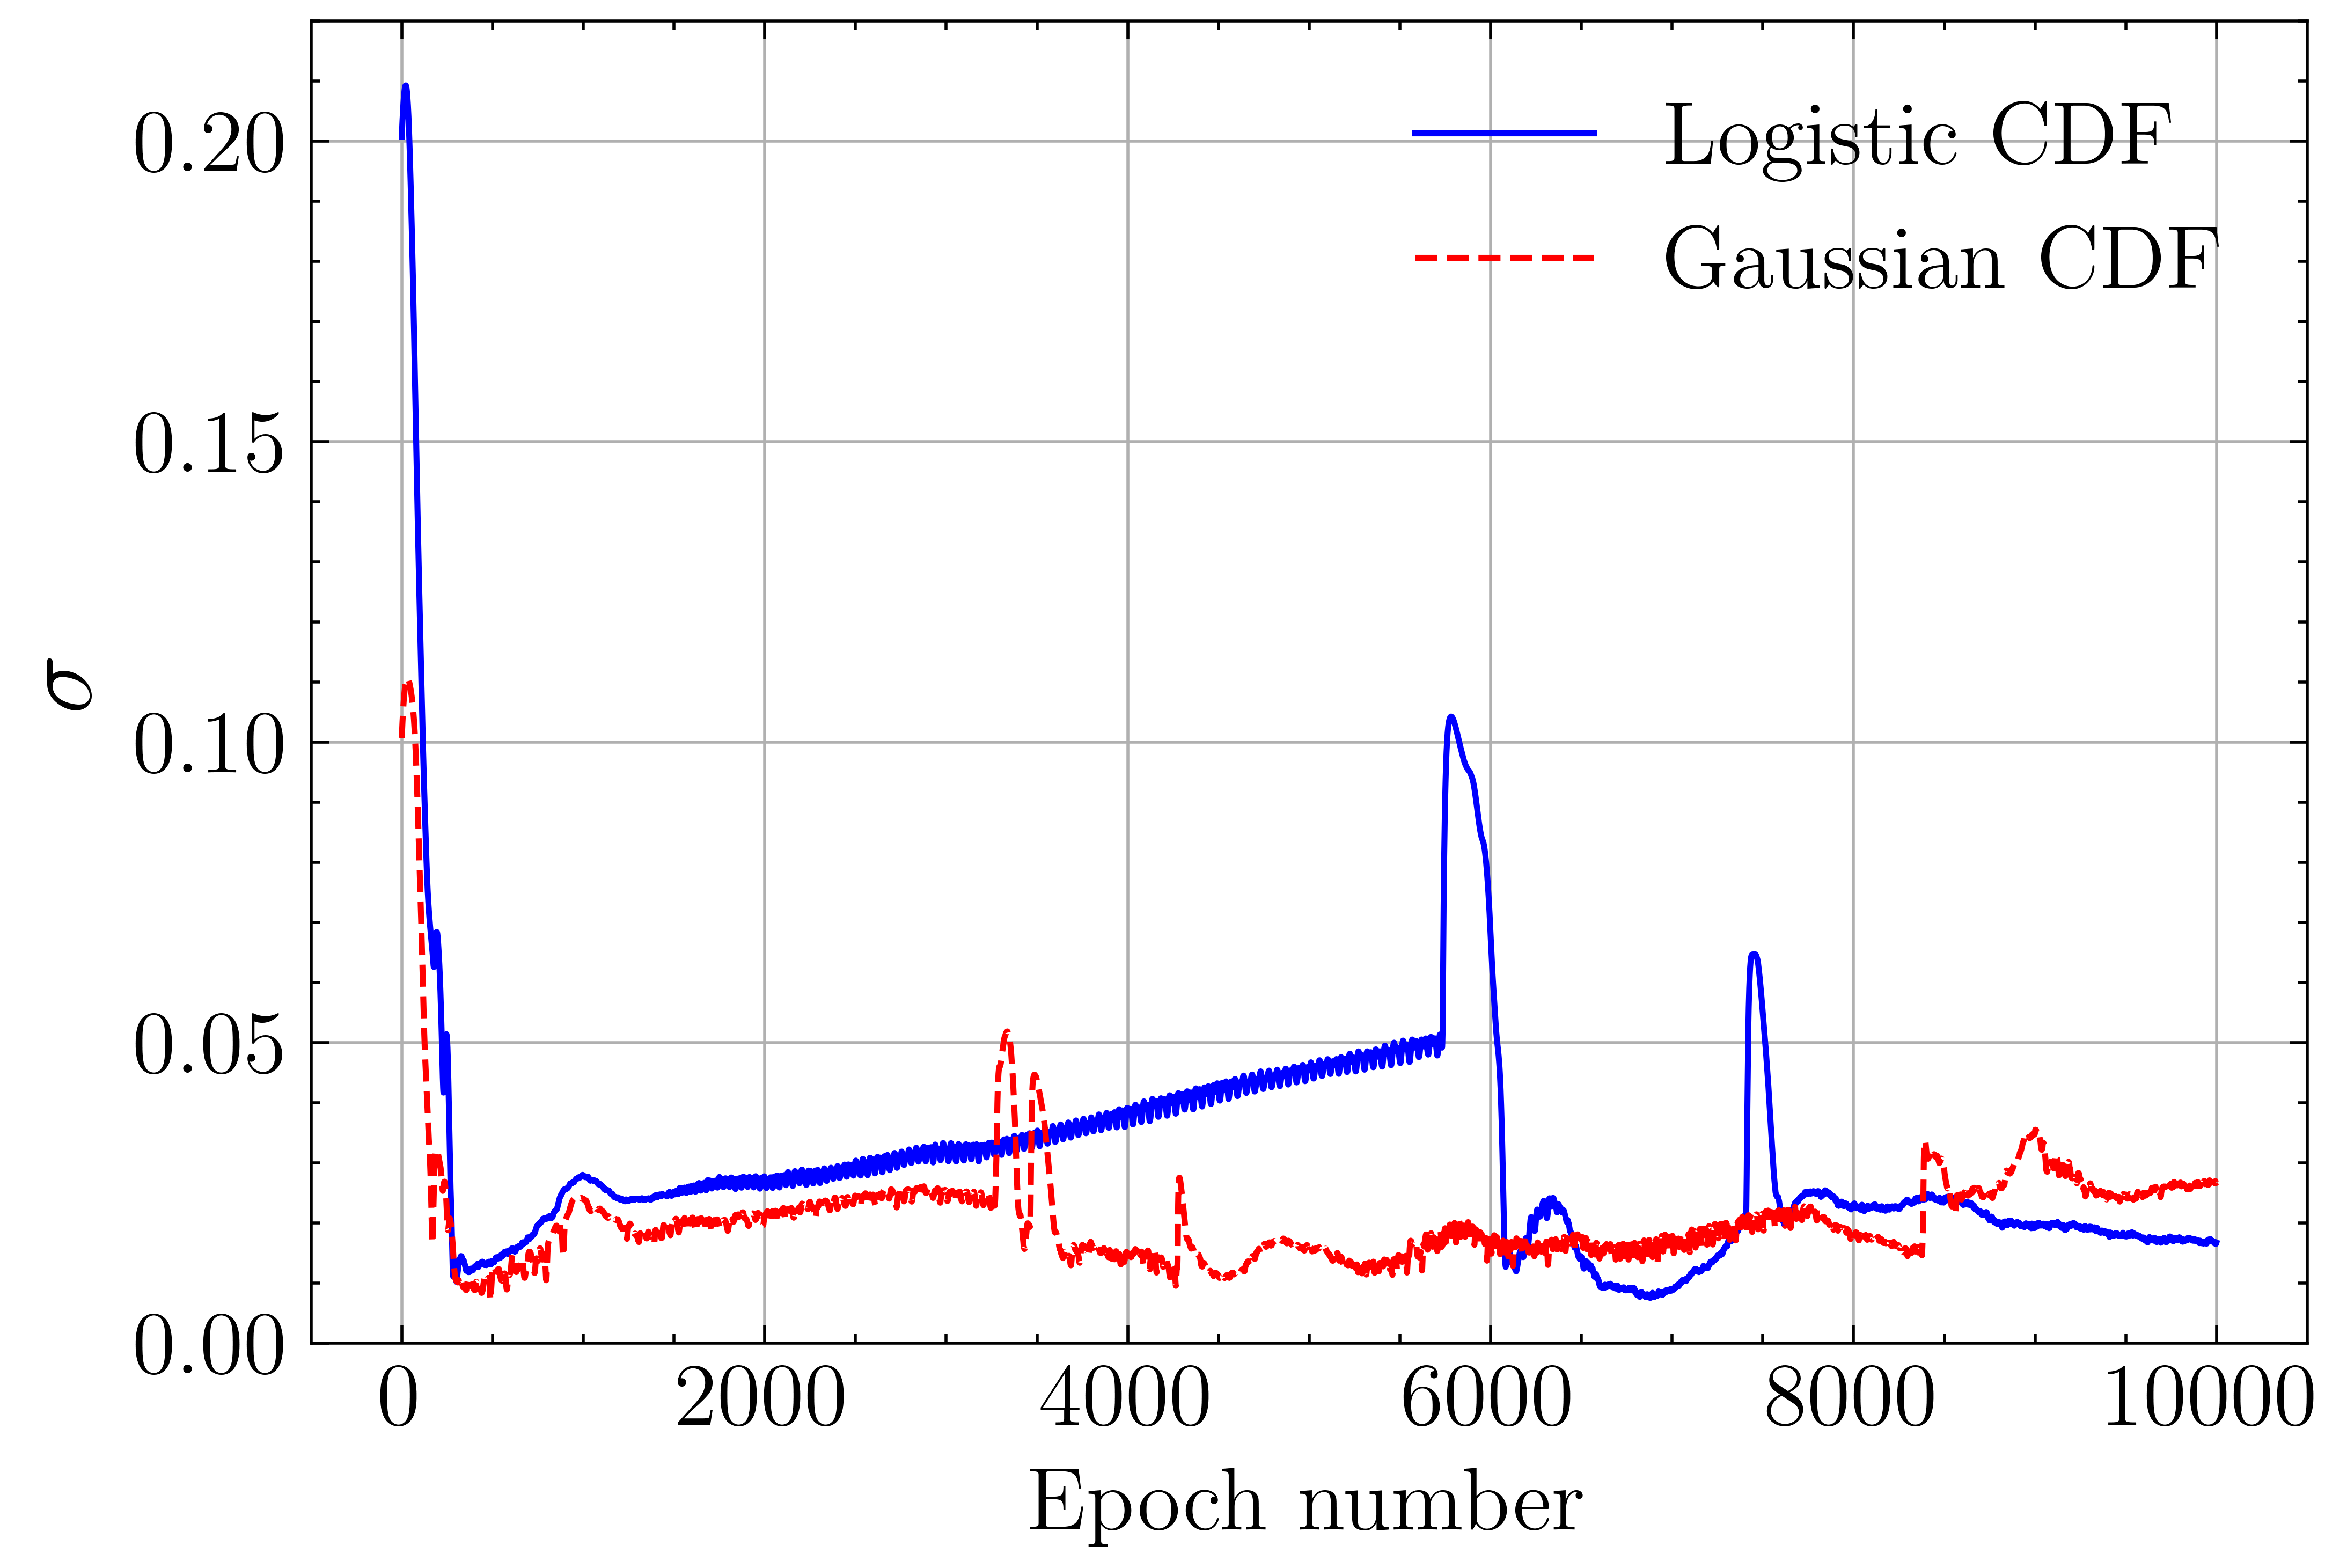

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

# 设置样式
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

# 载入两组 sigma 数据
sigma_sig = np.load("D:/PRE2023 2025/epoch_sigma_valuessig742.npy")
sigma_geu = np.load("D:/PRE2023 2025/epoch_sigma_valuesGEU742-2.npy")

# 绘图
plt.figure(figsize=(6, 4))
ax = plt.gca()  # 获取当前轴对象

ax.plot(sigma_sig, label='Logistic CDF', color='blue', linestyle='-')
ax.plot(sigma_geu, label='Gaussian CDF', color='red', linestyle='--')

ax.set_xlabel('Epoch number', fontsize=15)
ax.set_ylabel(r'$\sigma$', fontsize=17)
ax.tick_params(labelsize=15)  # 设置坐标轴刻度字体大小
ax.set_ylim(0.0, 0.22)
ax.grid(True)
ax.legend(fontsize=15)
plt.savefig("D:/PRE2023 2025/Fig4.eps", dpi=1000)
plt.show()



In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
import math

# 设置 matplotlib 样式和字体
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 生成真实数据（多环高斯分布）
def gen_gauss(p, n=1, r=1):
    x, y = [], []
    for k in range(n):
        mean = [math.sin(2 * k * math.pi / n), math.cos(2 * k * math.pi / n)]
        cov = [[0.0125, 0], [0, 0.0125]]
        x_t, y_t = np.random.multivariate_normal(mean, cov, p).T
        x.append(x_t)
        y.append(y_t)
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)
    return train / (np.max(train) * r)

# 设置随机种子并生成真实数据
seed = 742
np.random.seed(seed)
X_train = gen_gauss(p=100, n=5, r=0.5)

# 设置数据路径
data_path = "D:/PRE2023 2025/"

# 加载生成数据和梯度范数数据
samples_files = ["generated_samples742.npy", "sampleGEU742.npy", "sample742sig.npy"]
gradnorm_files = ["epoch_generator_grad_norm742.npy", "epoch_generator_grad_normGEU742.npy", "epoch_generator_grad_normsig742.npy"]

samples_list = [np.load(data_path + f) for f in samples_files]
grad_norms_list = [np.load(data_path + f) for f in gradnorm_files]

# 创建 2x3 子图布局
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：真实 vs 生成数据
for i in range(3):
    ax = axes[0, i]
    ax.set_xlabel(r'$x_1$', fontsize=22)
    if i == 0:
        ax.set_ylabel(r'$x_2$', fontsize=22)
    else:
        ax.set_ylabel('')  # 只隐藏标签，不隐藏刻度

    ax.tick_params(labelsize=22)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data',
               marker='o', s=8)
    ax.scatter(samples_list[i][:, 0], samples_list[i][:, 1], color="blue", 
               label='Generated data', marker='o', facecolors='none', 
               edgecolors='blue', s=5)
    ax.legend(loc='lower left', bbox_to_anchor=(-0.08, -0.05), fontsize=15)
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.grid(True, alpha=1.0)
    
    # 添加子图标注 (a), (b), (c)
    ax.text(-3.2, 2.3, f'({chr(97+i)})', fontsize=22, fontweight='bold')

# 第二行：Generator 梯度范数曲线
for i in range(3):
    ax = axes[1, i]
    ax.set_xlabel('Epoch number', fontsize=22)
    if i == 0:
        ax.set_ylabel(r'$\| \nabla_\theta \mathcal{L}_G \|_2$', fontsize=22)
    else:
        ax.set_ylabel('')  # 只隐藏标签，不隐藏刻度

    ax.tick_params(labelsize=22)

    grad_norm = grad_norms_list[i]
    grad_norm = np.clip(grad_norm, a_min=1e-12, a_max=None)
    log_grad_norm = np.log(grad_norm) / 2

    ax.plot(np.arange(len(grad_norm)), log_grad_norm, color='green', linewidth=1.5)
    ax.grid(True, alpha=1.0)
    ax.set_ylim(-5, 4)
    ax.set_yticks(np.arange(-5, 5, 1))
    ax.set_xticks([0, 2500, 5000, 7500, 10000])

    # 添加子图标注 (d), (e), (f)
    ax.text(-2500, 3.8, f'({chr(100+i)})', fontsize=22, fontweight='bold')

# 调整子图间距
plt.tight_layout()

# 保存图像（可选）
plt.savefig('D:/PRE2023 2025/Fig3.eps', dpi=1000, bbox_inches='tight')

Epoch     0 | D Loss: 3.4527 | G Loss: -0.0555 | σ: 0.0500
Epoch   100 | D Loss: 1.0021 | G Loss: -0.4518 | σ: 0.0502
Epoch   200 | D Loss: 1.0931 | G Loss: -0.4607 | σ: 0.0486
Epoch   300 | D Loss: 0.6644 | G Loss: -0.2466 | σ: 0.0471
Epoch   400 | D Loss: 0.7474 | G Loss: -0.2763 | σ: 0.0457
Epoch   500 | D Loss: 0.7254 | G Loss: -0.2529 | σ: 0.0438
Epoch   600 | D Loss: 0.7399 | G Loss: -0.3006 | σ: 0.0419
Epoch   700 | D Loss: 0.7466 | G Loss: -0.2481 | σ: 0.0409
Epoch   800 | D Loss: 0.8583 | G Loss: -0.2801 | σ: 0.0403
Epoch   900 | D Loss: 0.9412 | G Loss: -0.3316 | σ: 0.0401
Epoch  1000 | D Loss: 0.9933 | G Loss: -0.3461 | σ: 0.0400
Epoch  1100 | D Loss: 0.9944 | G Loss: -0.3017 | σ: 0.0394
Epoch  1200 | D Loss: 0.9865 | G Loss: -0.3255 | σ: 0.0393
Epoch  1300 | D Loss: 1.0144 | G Loss: -0.3356 | σ: 0.0393
Epoch  1400 | D Loss: 1.1289 | G Loss: -0.3166 | σ: 0.0388
Epoch  1500 | D Loss: 1.0409 | G Loss: -0.3530 | σ: 0.0393
Epoch  1600 | D Loss: 1.0546 | G Loss: -0.3453 | σ: 0.03

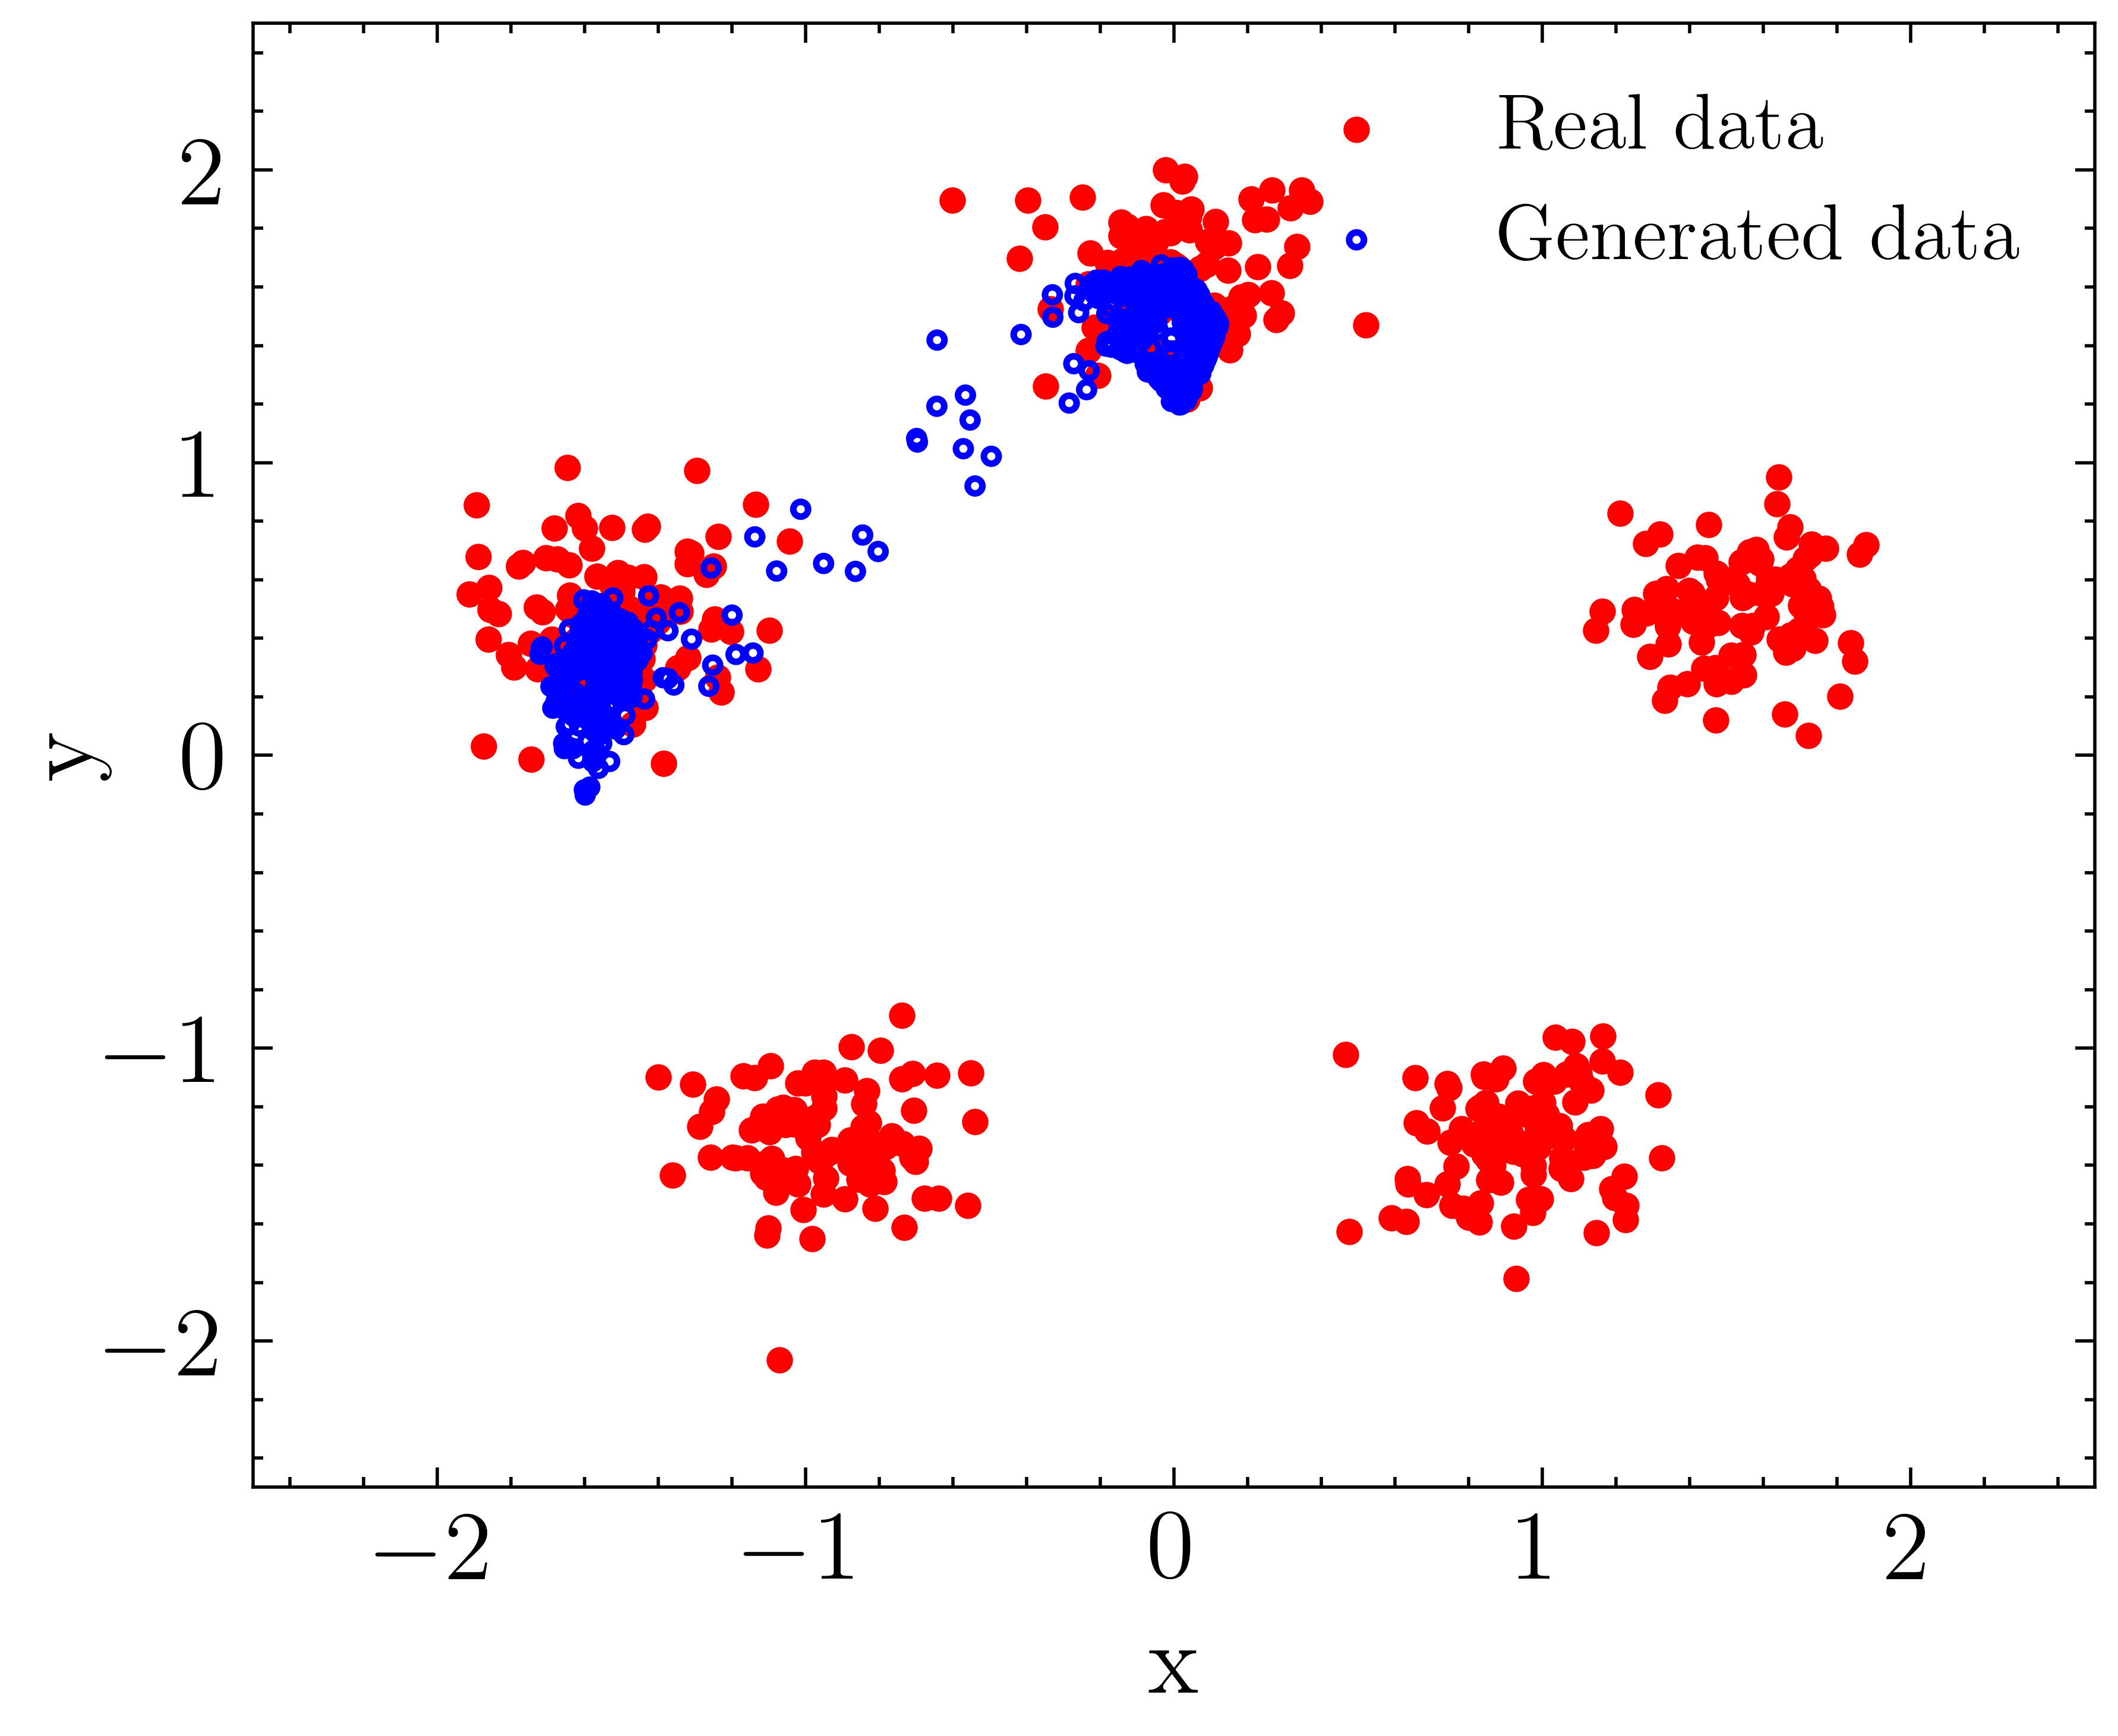


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.2700
Precision（生成样本落入真实密度区域比例）: 0.9730


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

# 设置随机种子
seed = 742
torch.manual_seed(seed)
np.random.seed(seed)

# 生成二维高斯混合数据
def genGauss(p, n=1, r=1):
    x, y = [], []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal(
            [math.sin(2 * k * math.pi / n), math.cos(2 * k * math.pi / n)],
            [[0.0125, 0], [0, 0.0125]], p
        ).T
        x.append(x_t)
        y.append(y_t)
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)
    return train / (np.max(train) * r)

# Generator 网络
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, h1, h2, h3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, h3), nn.ReLU(),
            nn.Linear(h3, x_dim)
        )

    def forward(self, z):
        return self.model(z)

# GEU 激活函数，使用 softplus 保证 sigma > 0
class GEU(nn.Module):
    def __init__(self, init_sigma=0.05):
        super().__init__()
        # 初始化时对raw_sigma取对数，这样初始sigma=exp(raw_sigma)=init_sigma
        self.raw_sigma = nn.Parameter(torch.log(torch.tensor(init_sigma)))

    def forward(self, input):
        eps = 1e-6
        sigma = torch.exp(self.raw_sigma)  # 保证sigma严格大于0
        denom = math.sqrt(2.0) * sigma
        output = 0.5 * (1 + torch.erf(input / denom))
        return output

    @property
    def sigma(self):
        return torch.exp(self.raw_sigma)

# Discriminator 网络
class Discriminator(nn.Module):
    def __init__(self, x_dim, h1, h2, h3):
        super().__init__()
        self.fc1 = nn.Linear(x_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fc4 = nn.Linear(h3, 1)
        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d = self.relu(self.fc1(x_input))
        d = self.relu(self.fc2(d))
        d = self.relu(self.fc3(d))
        d_out = self.fc4(d)
        return self.GEU(d_out), d_out

# 自定义判别器损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# 超参数设置
nb_neurons_h1 = nb_neurons_h2 = nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
z_dim = x_dim = 2
epochs = 10000

# 初始化网络和优化器
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

# 生成训练数据
X_train = torch.tensor(genGauss(100, 5, 0.5), dtype=torch.float32)
X_train = X_train[torch.randperm(X_train.size(0))]  # shuffle

# 记录指标
epoch_discriminator_loss, epoch_generator_loss = [], []
epoch_generator_grad_norm, epoch_sigma_values = [], []

# 训练主循环
for epoch in range(epochs):
    d_loss_list, g_loss_list, g_grad_norm_list = [], [], []
    nb_batches = X_train.shape[0] // batch_size

    for i in range(nb_batches):
        real_batch = X_train[i * batch_size:(i + 1) * batch_size]
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # 更新判别器
        d_real, _ = discriminator(real_batch)
        d_fake, _ = discriminator(fake_img.detach())
        d_loss = discriminator_loss(d_real, d_fake)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # 更新生成器
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))
        g_optimizer.zero_grad()
        g_loss.backward()

        # 记录生成器梯度范数
        total_norm = sum((p.grad.data.norm(2) ** 2 for p in generator.parameters() if p.grad is not None))
        g_grad_norm_list.append(total_norm)

        g_optimizer.step()
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())

    # 每个 epoch 的指标
    epoch_discriminator_loss.append(np.mean(d_loss_list))
    epoch_generator_loss.append(np.mean(g_loss_list))
    epoch_generator_grad_norm.append(np.mean(g_grad_norm_list))
    epoch_sigma_values.append(discriminator.GEU.sigma.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:5d} | D Loss: {d_loss_list[-1]:.4f} | "
              f"G Loss: {g_loss_list[-1]:.4f} | σ: {epoch_sigma_values[-1]:.4f}")

# 生成并可视化生成器输出
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

samples = generator(torch.randn(1000, z_dim)).detach().numpy()
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data',
           marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
plt.show()

# 质量评价函数
def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    X_all = np.concatenate([X_real, X_fake])
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])
    knn = KNeighborsClassifier(n_neighbors=1).fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    one_nn_acc = max(accuracy_score(y_all, y_pred), 1 - accuracy_score(y_all, y_pred))

    dists_real_to_fake = cdist(X_real, X_fake)
    coverage = np.mean(np.min(dists_real_to_fake, axis=1) < eps)

    dists_fake_to_real = cdist(X_fake, X_real)
    precision = np.mean(np.min(dists_fake_to_real, axis=1) < eps)

    return {'1NN_acc': one_nn_acc, 'Coverage': coverage, 'Precision': precision}

# 调用评估
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)
print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")
